In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("seaborn :", sns.__version__)
print("\nAll libraries loaded ✓")

pandas  : 2.3.3
numpy   : 2.4.1
seaborn : 0.13.2

All libraries loaded ✓


# Flowmetric — SaaS Subscription Health & Churn Analysis

**Company:** Flowmetric (fictional) — B2B SaaS platform for creative & consulting agencies  
**Markets:** United States, United Kingdom, Germany, Portugal  
**Period:** July 2023 – June 2026 (36 months)  
**Data:** Synthetic dataset generated with realistic SaaS business logic

## Objective
Investigate 4 business questions on behalf of the CEO:
1. Is MRR growing or shrinking? *(Revenue Health)*
2. Who churns, when, and in which segments? *(Churn Analysis)*
3. Which segments generate the most lifetime value? *(LTV)*
4. Can we predict churn before it happens? *(Engagement & Early Warning)*

In [2]:
# ── Load datasets ──────────────────────────────────────────────────────────
customers     = pd.read_csv("../data/raw/customers.csv", parse_dates=["signup_date"])
plans         = pd.read_csv("../data/raw/plans.csv")
subscriptions = pd.read_csv("../data/raw/subscriptions.csv", parse_dates=["start_date", "end_date"])
events        = pd.read_csv("../data/raw/events.csv", parse_dates=["event_date"])
payments      = pd.read_csv("../data/raw/payments.csv", parse_dates=["payment_date"])

# ── Quick overview ─────────────────────────────────────────────────────────
tables = {
    "customers"    : customers,
    "plans"        : plans,
    "subscriptions": subscriptions,
    "events"       : events,
    "payments"     : payments,
}

for name, df in tables.items():
    print(f"{name:>15} — {len(df):>7,} rows  ×  {df.shape[1]} cols")

      customers —   1,000 rows  ×  6 cols
          plans —       3 rows  ×  5 cols
  subscriptions —   1,094 rows  ×  7 cols
         events — 202,305 rows  ×  4 cols
       payments —  11,410 rows  ×  6 cols


## Data Loading

Five tables loaded successfully from `data/raw/`:

| Table | Rows | Description |
|---|---|---|
| `customers` | 1,000 | One row per client company |
| `plans` | 3 | Starter / Pro / Enterprise plan definitions |
| `subscriptions` | 1,094 | Subscription history — more rows than customers because plan changes (upgrades/downgrades) create new records |
| `events` | 202,305 | Granular product usage log — every login, project, invoice, time entry |
| `payments` | 11,410 | Monthly billing records including failed payments and retries |

> **Note:** The difference between 1,000 customers and 1,094 subscriptions is intentional and meaningful — it tells us some customers changed plan at least once. We will quantify this in the analysis.

## Data Quality Assessment

Before any analysis we need to understand what we are working with.  
We check for: missing values, duplicates, and formatting inconsistencies.

In [3]:
# ── Missing values per table ───────────────────────────────────────────────
print("=" * 45)
print("MISSING VALUES")
print("=" * 45)

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n[{name}]")
        for col, n in missing.items():
            print(f"  {col:>20}: {n:>5} missing  ({n/len(df)*100:.1f}%)")
    else:
        print(f"\n[{name}] — no missing values")

MISSING VALUES

[customers]
              industry:    20 missing  (2.0%)

[plans] — no missing values

[subscriptions]
              end_date:   654 missing  (59.8%)

[events]
            event_type:  1012 missing  (0.5%)

[payments] — no missing values


In [4]:
# ── Duplicate rows per table ───────────────────────────────────────────────
print("=" * 45)
print("DUPLICATE ROWS")
print("=" * 45)

for name, df in tables.items():
    n_dupes = df.duplicated().sum()
    status = "⚠️  needs attention" if n_dupes > 0 else "✓"
    print(f"  {name:>15}: {n_dupes:>5} duplicate rows  {status}")

DUPLICATE ROWS
        customers:     0 duplicate rows  ✓
            plans:     0 duplicate rows  ✓
    subscriptions:     0 duplicate rows  ✓
           events:  1983 duplicate rows  ⚠️  needs attention
         payments:     0 duplicate rows  ✓


In [5]:
# ── Country field inconsistencies ─────────────────────────────────────────
print("=" * 45)
print("COUNTRY — all unique values")
print("=" * 45)

print(customers["country"].value_counts().to_string())

COUNTRY — all unique values
country
United States       374
United Kingdom      262
Germany             193
Portugal            137
 United States        6
united states         4
Untd Kingdom          4
united kingdom        3
GERMANY               3
 Portugal             3
 United Kingdom       2
portugal              2
UNITED STATES         2
germany               2
UNITED KINGDOM        1
Untd States           1
 Germany              1


## Data Quality Summary

| Table | Issue | Rows Affected | Type |
|---|---|---|---|
| `customers` | Missing `industry` | 20 (2.0%) | Incomplete CRM data |
| `subscriptions` | Missing `end_date` | 654 (59.8%) | Expected — active subscriptions have no end date |
| `events` | Missing `event_type` | 1,012 (0.5%) | Tracking pipeline bug |
| `events` | Duplicate rows | 1,983 (1.0%) | Double-firing in event tracking system |
| `customers` | Inconsistent `country` formatting | 43 rows | Multi-source data entry (whitespace, casing, abbreviations) |

**Decision before cleaning:**
- `subscriptions.end_date` — will **not** be treated as missing data. Null = active customer.
- All other issues will be corrected in the cleaning step below.

## Data Cleaning

We clean each issue identified above in isolation, working on copies of the  
original dataframes so raw data is always preserved unchanged.

In [6]:
# ── Clean 1: country field ─────────────────────────────────────────────────
customers_clean = customers.copy()

customers_clean["country"] = (
    customers_clean["country"]
    .str.strip()                                    # remove leading/trailing spaces
    .str.title()                                    # Title Case
    .str.replace(r"^Untd\s+", "United ", regex=True)  # fix "Untd" abbreviation
)

print("Country values after cleaning:")
print(customers_clean["country"].value_counts().to_string())

Country values after cleaning:
country
United States     387
United Kingdom    272
Germany           199
Portugal          142


In [7]:
# ── Clean 2: missing industry ──────────────────────────────────────────────
missing_before = customers_clean["industry"].isna().sum()

customers_clean["industry"] = customers_clean["industry"].fillna("Unknown")

missing_after = customers_clean["industry"].isna().sum()

print(f"Missing industry before: {missing_before}")
print(f"Missing industry after:  {missing_after}")
print(f"\nIndustry distribution:")
print(customers_clean["industry"].value_counts().to_string())

Missing industry before: 20
Missing industry after:  0

Industry distribution:
industry
PR Agency                         150
Dev Shop / Software Consulting    148
Digital Agency                    141
Marketing Agency                  140
Management Consulting             137
Branding Agency                   134
Design Studio                     130
Unknown                            20


In [8]:
# ── Clean 3: duplicate events ──────────────────────────────────────────────
events_clean = events.copy()

before = len(events_clean)
events_clean = events_clean.drop_duplicates()
after = len(events_clean)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed:     {before - after:,} duplicate rows")

Rows before: 202,305
Rows after:  200,322
Removed:     1,983 duplicate rows


In [9]:
# ── Clean 4: missing event_type ───────────────────────────────────────────
missing_before = events_clean["event_type"].isna().sum()

events_clean["event_type"] = events_clean["event_type"].fillna("unknown")

missing_after = events_clean["event_type"].isna().sum()

print(f"Missing event_type before: {missing_before}")
print(f"Missing event_type after:  {missing_after}")
print(f"\nEvent type distribution:")
print(events_clean["event_type"].value_counts().to_string())

Missing event_type before: 1012
Missing event_type after:  0

Event type distribution:
event_type
task_assigned            32934
login                    32776
project_created          32603
invoice_sent             31544
report_exported          31428
time_logged              31269
team_member_invited       2288
client_invited            2251
support_ticket_opened     2217
unknown                   1012


In [10]:
# ── Clean 5: subscriptions — add computed columns ─────────────────────────
ANALYSIS_DATE = pd.Timestamp("2026-06-30")

subs_clean = subscriptions.copy()

# Active subscriptions have no end_date — fill with analysis date for calculations
subs_clean["end_date_filled"] = subs_clean["end_date"].fillna(ANALYSIS_DATE)

# Duration in days
subs_clean["duration_days"] = (
    subs_clean["end_date_filled"] - subs_clean["start_date"]
).dt.days

# Add plan name and tier from plans table
subs_clean = subs_clean.merge(
    plans[["plan_id", "plan_name", "tier"]],
    on="plan_id"
)

print("Subscriptions clean — shape:", subs_clean.shape)
print("\nStatus distribution:")
print(subs_clean["status"].value_counts().to_string())
print("\nSample:")
print(subs_clean[["subscription_id", "customer_id", "plan_name",
                   "status", "mrr_amount", "duration_days"]].head(8).to_string(index=False))

Subscriptions clean — shape: (1094, 11)

Status distribution:
status
active        654
churned       346
upgraded       48
downgraded     46

Sample:
 subscription_id  customer_id plan_name  status  mrr_amount  duration_days
               1            1   Starter churned          49            174
               2            2       Pro  active         199            878
               3            3   Starter churned          49            196
               4            4       Pro  active         199            255
               5            5       Pro  active         199            149
               6            6   Starter  active          49            268
               7            7   Starter churned          49             -3
               8            8   Starter  active          49             67


In [11]:
# ── Investigate negative duration ─────────────────────────────────────────
bad_dates = subs_clean[subs_clean["duration_days"] < 0]

print(f"Subscriptions with negative duration: {len(bad_dates)}")
print()
print(bad_dates[["subscription_id", "customer_id", "plan_name",
                  "status", "start_date", "end_date", "duration_days"]].to_string(index=False))

Subscriptions with negative duration: 33

 subscription_id  customer_id  plan_name  status start_date   end_date  duration_days
               7            7    Starter churned 2025-07-04 2025-07-01             -3
              24           23    Starter churned 2025-11-14 2025-11-01            -13
              45           43    Starter churned 2024-02-04 2024-02-01             -3
              93           83    Starter churned 2026-06-22 2026-06-01            -21
             145          129    Starter churned 2026-03-15 2026-03-01            -14
             146          130    Starter churned 2025-07-24 2025-07-01            -23
             161          145    Starter churned 2026-06-24 2026-06-01            -23
             162          146    Starter churned 2026-06-21 2026-06-01            -20
             171          155 Enterprise churned 2024-05-10 2024-05-01             -9
             182          165    Starter churned 2026-06-06 2026-06-01             -5
            

In [12]:
# ── Clean 6: fix negative duration_days ───────────────────────────────────
negative_mask = subs_clean["duration_days"] < 0

print(f"Rows to fix: {negative_mask.sum()}")
print(f"duration_days before fix (sample): {subs_clean.loc[negative_mask, 'duration_days'].values[:5]}")

subs_clean.loc[negative_mask, "duration_days"] = 0

print(f"\nRows with negative duration after fix: {(subs_clean['duration_days'] < 0).sum()}")
print(f"duration_days after fix (sample):  {subs_clean.loc[negative_mask, 'duration_days'].values[:5]}")

Rows to fix: 33
duration_days before fix (sample): [ -3 -13  -3 -21 -14]

Rows with negative duration after fix: 0
duration_days after fix (sample):  [0 0 0 0 0]


In [13]:
# ── Cleaning summary ───────────────────────────────────────────────────────
print("=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)

print(f"""
customers_clean
  country inconsistencies fixed : 43 rows normalised
  missing industry filled       : 20 rows → 'Unknown'

events_clean
  duplicate rows removed        : 1,983 rows dropped
  missing event_type filled     : 1,012 rows → 'unknown'

subs_clean
  plan name/tier joined         : from plans table
  end_date_filled created       : 654 nulls → analysis date
  duration_days calculated      : end_date - start_date
  negative duration fixed       : 33 rows → 0 days

payments_clean
  no issues found               : ✓
""")

print("Clean dataframes ready:")
for name, df in [("customers_clean", customers_clean),
                 ("events_clean",    events_clean),
                 ("subs_clean",      subs_clean)]:
    print(f"  {name:>18}: {len(df):>7,} rows")

CLEANING SUMMARY

customers_clean
  country inconsistencies fixed : 43 rows normalised
  missing industry filled       : 20 rows → 'Unknown'

events_clean
  duplicate rows removed        : 1,983 rows dropped
  missing event_type filled     : 1,012 rows → 'unknown'

subs_clean
  plan name/tier joined         : from plans table
  end_date_filled created       : 654 nulls → analysis date
  duration_days calculated      : end_date - start_date
  negative duration fixed       : 33 rows → 0 days

payments_clean
  no issues found               : ✓

Clean dataframes ready:
     customers_clean:   1,000 rows
        events_clean: 200,322 rows
          subs_clean:   1,094 rows


## Data Cleaning — Summary

All identified issues have been resolved. Key decisions made:

- **`country`** — Normalised to Title Case, stripped whitespace, fixed "Untd" abbreviation.
  Result: 4 clean values (United States, United Kingdom, Germany, Portugal)
- **`industry`** — 20 missing values filled as `'Unknown'`. Rows preserved — dropping them
  would lose valid subscription and payment data for those customers.
- **`events` duplicates** — 1,983 exact duplicate rows removed. These are technical duplicates
  (same event_id, customer, date and type) caused by double-firing in the tracking pipeline,
  not real repeated user actions.
- **`event_type`** — 1,012 missing values filled as `'unknown'`. Tagged for visibility,
  not dropped, as the customer and date context is still analytically useful.
- **`end_date` (subscriptions)** — 654 nulls are expected: they represent currently active
  subscriptions. Filled with the analysis date (2026-06-30) for duration calculations only.
- **`duration_days`** — 33 negative values corrected to 0. These are customers who signed up
  and churned within the same billing month — a real business scenario (early churn).

> Raw data files are preserved unchanged in `data/raw/`.  
> All analysis from this point forward uses the cleaned dataframes.

## Block 1 — Revenue Health

**Business question:** Is MRR growing or shrinking? What is driving the change?

**KPIs:**
- KPI 1: Total MRR per month (36-month trend)
- KPI 2: MRR movement breakdown — New / Expansion / Contraction / Churned
- KPI 3: Net Revenue Retention (NRR)

In [14]:
# ── KPI 1: Total MRR per month ─────────────────────────────────────────────
ANALYSIS_DATE = pd.Timestamp("2026-06-30")
months = pd.date_range(start="2023-07-01", end="2026-06-01", freq="MS")

mrr_records = []
for m in months:
    m_end = m + pd.offsets.MonthEnd(0)
    active = subs_clean[
        (subs_clean["start_date"] <= m_end) &
        (subs_clean["end_date_filled"] >= m)
    ]
    mrr_records.append({
        "month"      : m,
        "total_mrr"  : active["mrr_amount"].sum(),
        "n_customers": active["customer_id"].nunique(),
    })

mrr_df = pd.DataFrame(mrr_records)

print(f"First month MRR : €{mrr_df.iloc[0].total_mrr:,.0f}")
print(f"Last month MRR  : €{mrr_df.iloc[-1].total_mrr:,.0f}")
print(f"Growth (36m)    : {((mrr_df.iloc[-1].total_mrr / mrr_df.iloc[0].total_mrr)-1)*100:.1f}%")
print(f"\nPeak MRR month  : {mrr_df.loc[mrr_df.total_mrr.idxmax(), 'month'].strftime('%b %Y')}")
print(f"Peak MRR value  : €{mrr_df.total_mrr.max():,.0f}")
print(f"\nSample (first 3 and last 3 months):")
print(pd.concat([mrr_df.head(3), mrr_df.tail(3)]).to_string(index=False))

First month MRR : €3,689
Last month MRR  : €222,317
Growth (36m)    : 5926.5%

Peak MRR month  : Jun 2026
Peak MRR value  : €222,317

Sample (first 3 and last 3 months):
     month  total_mrr  n_customers
2023-07-01       3689           11
2023-08-01       6429           21
2023-09-01       7871           29
2026-04-01     201105          638
2026-05-01     206340          656
2026-06-01     222317          676


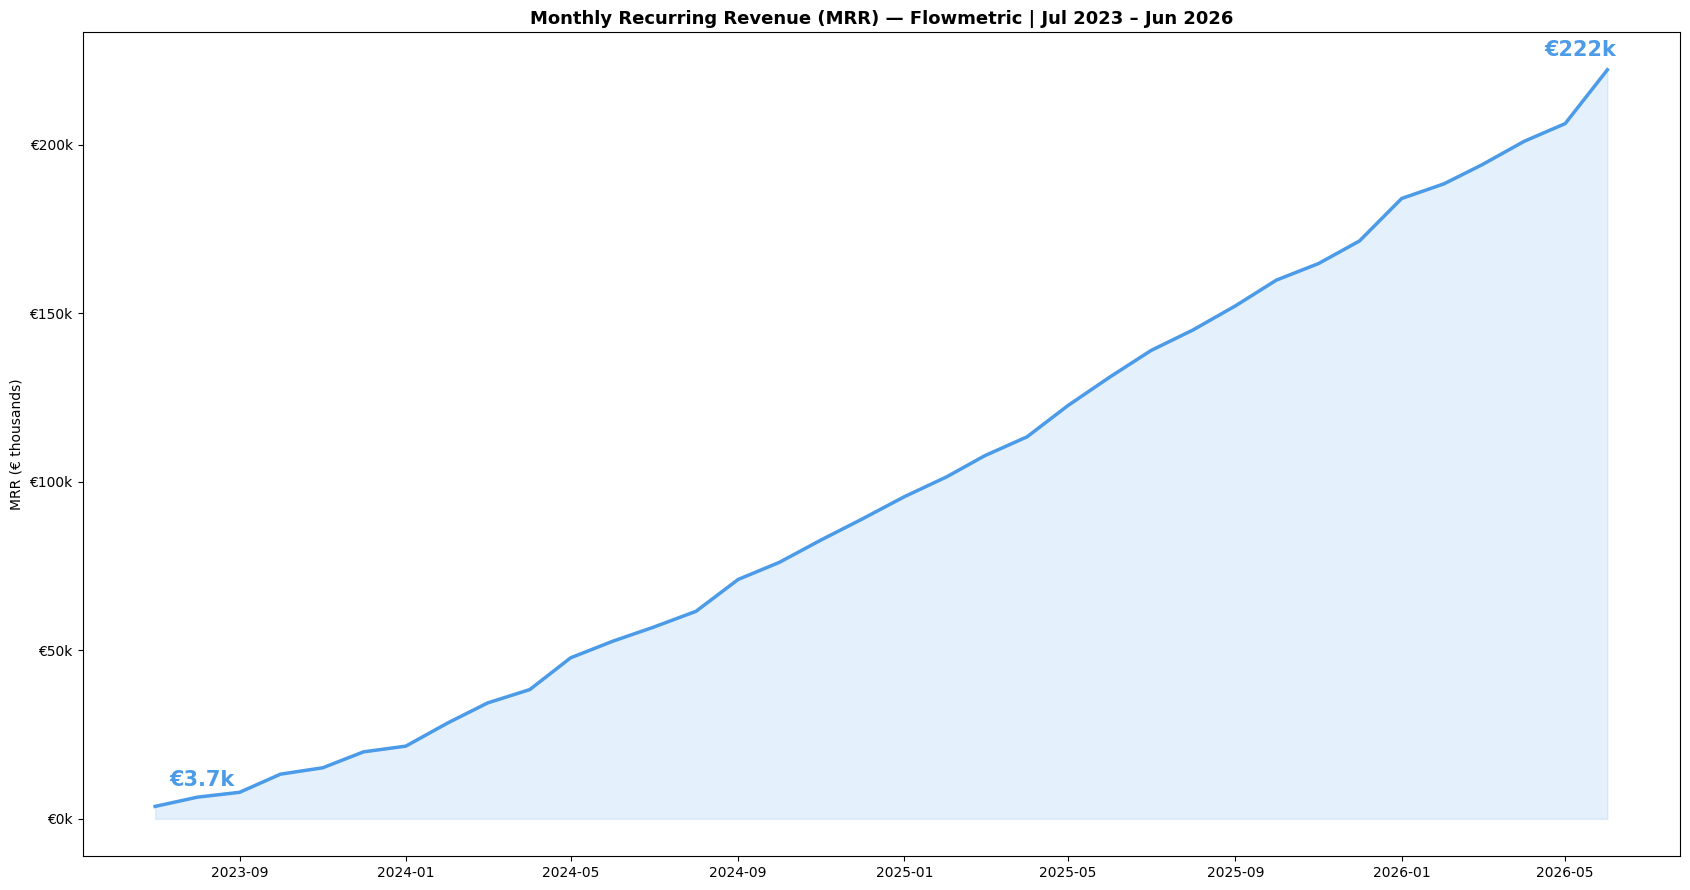

In [15]:
# ── KPI 1: MRR trend chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 9))

ax.fill_between(mrr_df["month"], mrr_df["total_mrr"] / 1000,
                alpha=0.15, color="#4C9BE8")
ax.plot(mrr_df["month"], mrr_df["total_mrr"] / 1000,
        color="#4C9BE8", linewidth=2.5)

# Annotate first and last point
ax.annotate(f"€{mrr_df.iloc[0].total_mrr/1000:.1f}k",
            xy=(mrr_df.iloc[0].month, mrr_df.iloc[0].total_mrr/1000),
            xytext=(10, 15), textcoords="offset points",
            fontsize=15, color="#4C9BE8", fontweight="bold")

ax.annotate(f"€{mrr_df.iloc[-1].total_mrr/1000:.0f}k",
            xy=(mrr_df.iloc[-1].month, mrr_df.iloc[-1].total_mrr/1000),
            xytext=(-45, 10), textcoords="offset points",
            fontsize=15, color="#4C9BE8", fontweight="bold")

ax.set_title("Monthly Recurring Revenue (MRR) — Flowmetric | Jul 2023 – Jun 2026",
             fontsize=13, fontweight="bold")
ax.set_ylabel("MRR (€ thousands)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}k"))
plt.tight_layout()
plt.savefig("../images/fig_mrr_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 1 — Total MRR Trend

| Metric | Value |
|---|---|
| MRR — July 2023 (month 1) | €3,689 |
| MRR — June 2026 (month 36) | €222,317 |
| Total growth over 36 months | +5,927% |
| Customers — month 1 | 11 |
| Customers — month 36 | 676 |

**Interpretation:**  
Flowmetric grew MRR by ~60x over 36 months, consistent with a B2B SaaS company
in an active growth phase that has found product-market fit.  
The curve shows no plateau — revenue is still accelerating at the end of the period.  
The first 3 months were slow (€3k → €7k), typical of early-stage B2B where
sales cycles are longer and the first customers require significant onboarding effort.

### KPI 2 — MRR Movement Breakdown

In [16]:
# ── KPI 2: MRR Movement Breakdown ─────────────────────────────────────────
# For each month we classify MRR change into 4 types:
# New        = MRR from customers whose subscription started this month
# Expansion  = MRR gained from upgrades closing this month
# Contraction= MRR lost from downgrades closing this month
# Churned    = MRR lost from cancellations this month

new_mrr = (
    subs_clean[subs_clean["start_date"].dt.to_period("M")
               .dt.to_timestamp().isin(months)]
    .groupby(subs_clean["start_date"].dt.to_period("M").dt.to_timestamp())
    ["mrr_amount"].sum().rename("new_mrr")
)

churned_mrr = (
    subs_clean[subs_clean["status"] == "churned"]
    .groupby(subs_clean["end_date"].dt.to_period("M").dt.to_timestamp())
    ["mrr_amount"].sum().rename("churned_mrr")
)

expansion_mrr = (
    subs_clean[subs_clean["status"] == "upgraded"]
    .groupby(subs_clean["end_date"].dt.to_period("M").dt.to_timestamp())
    ["mrr_amount"].sum().rename("expansion_mrr")
)

contraction_mrr = (
    subs_clean[subs_clean["status"] == "downgraded"]
    .groupby(subs_clean["end_date"].dt.to_period("M").dt.to_timestamp())
    ["mrr_amount"].sum().rename("contraction_mrr")
)

waterfall = pd.concat(
    [new_mrr, churned_mrr, expansion_mrr, contraction_mrr], axis=1
).fillna(0)
waterfall = waterfall[waterfall.index.isin(months)]
waterfall["net_new"] = (
    waterfall["new_mrr"]
    + waterfall["expansion_mrr"]
    - waterfall["churned_mrr"]
    - waterfall["contraction_mrr"]
)

print("MRR Movement — total over 36 months:")
print(f"  New MRR        : €{waterfall['new_mrr'].sum():>10,.0f}")
print(f"  Expansion MRR  : €{waterfall['expansion_mrr'].sum():>10,.0f}")
print(f"  Contraction MRR: €{waterfall['contraction_mrr'].sum():>10,.0f}")
print(f"  Churned MRR    : €{waterfall['churned_mrr'].sum():>10,.0f}")
print(f"  Net New MRR    : €{waterfall['net_new'].sum():>10,.0f}")
print(f"\nSample (last 6 months):")
print(waterfall.tail(6).to_string())

MRR Movement — total over 36 months:
  New MRR        : €   290,456
  Expansion MRR  : €     7,002
  Contraction MRR: €    18,754
  Churned MRR    : €    48,154
  Net New MRR    : €   230,550

Sample (last 6 months):
            new_mrr  churned_mrr  expansion_mrr  contraction_mrr  net_new
2026-01-01    15598       2082.0          199.0           1996.0  11719.0
2026-02-01     8618       2333.0           49.0            799.0   5535.0
2026-03-01     8854       3230.0          646.0           1197.0   5073.0
2026-04-01    12044       1433.0          545.0            998.0  10158.0
2026-05-01     8211       2027.0          199.0            597.0   5786.0
2026-06-01    18800       4528.0          447.0            796.0  13923.0


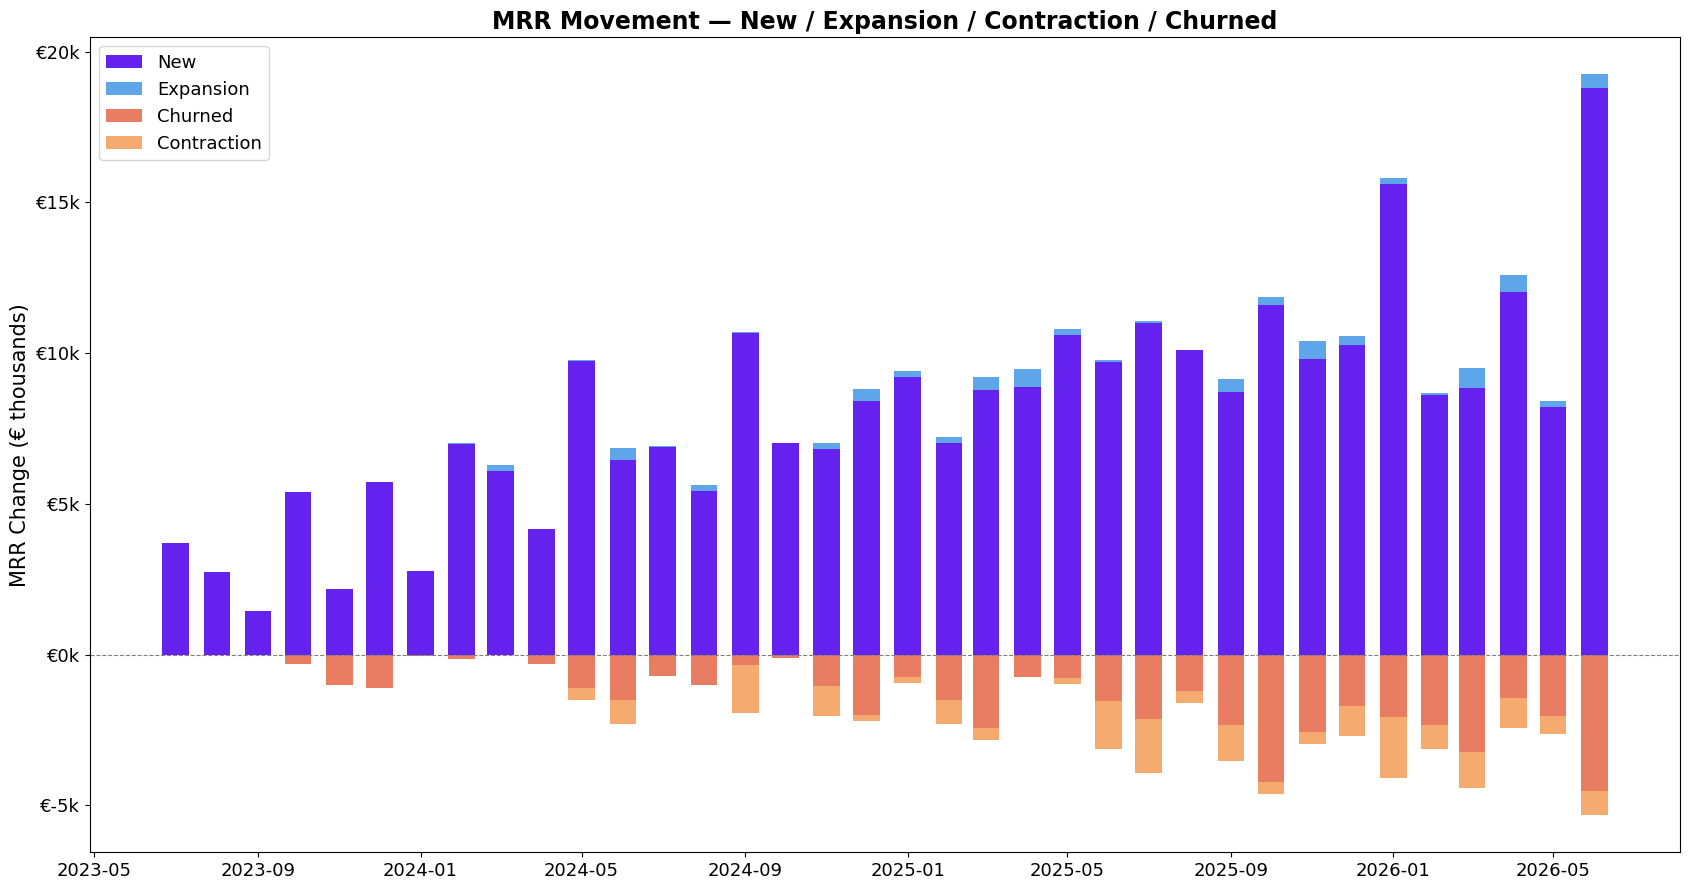

In [17]:
# ── KPI 2: MRR Movement chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 9))

ax.bar(waterfall.index, waterfall["new_mrr"] / 1000,
       label="New", color="#5409EB", alpha=0.9, width=20)
ax.bar(waterfall.index, waterfall["expansion_mrr"] / 1000,
       bottom=waterfall["new_mrr"] / 1000,
       label="Expansion", color="#4C9BE8", alpha=0.9, width=20)
ax.bar(waterfall.index, -waterfall["churned_mrr"] / 1000,
       label="Churned", color="#E76F51", alpha=0.9, width=20)
ax.bar(waterfall.index, -waterfall["contraction_mrr"] / 1000,
       bottom=-waterfall["churned_mrr"] / 1000,
       label="Contraction", color="#F4A261", alpha=0.9, width=20)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("MRR Movement — New / Expansion / Contraction / Churned",
             fontsize=17, fontweight="bold")
ax.set_ylabel("MRR Change (€ thousands)", fontsize=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}k"))
ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", labelsize=13)
ax.legend(loc="upper left", fontsize=13)
plt.tight_layout()
plt.savefig("../images/fig_mrr_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 2 — MRR Movement Breakdown

| Movement Type | Total (36 months) | Interpretation |
|---|---|---|
| New MRR | €290,456 | Revenue from new customers — main growth driver |
| Expansion MRR | €7,002 | Revenue gained from plan upgrades |
| Contraction MRR | €18,754 | Revenue lost from plan downgrades |
| Churned MRR | €48,154 | Revenue lost from cancellations |
| **Net New MRR** | **€230,550** | Net growth after all losses |

**Key insight:**  
New MRR is overwhelmingly the main growth driver — Flowmetric is growing
primarily through acquisition, not through expansion of existing customers.  
This is a risk: if acquisition slows down, revenue growth stalls immediately.

**Red flag:**  
Contraction MRR (€18,754) exceeds Expansion MRR (€7,002) — meaning more
revenue is being lost to downgrades than is being gained from upgrades.
Customers are stepping down before cancelling, which is a classic pre-churn signal.
A focus on upsell and account expansion would significantly improve net revenue retention.

### KPI 3 — Net Revenue Retention (NRR)

In [18]:
# ── KPI 3: Net Revenue Retention (NRR) ────────────────────────────────────
# NRR answers: of the revenue we had 12 months ago, how much do we have today
# from those same customers (including expansions and contractions)?
# Formula: NRR = (Starting MRR + Expansion - Contraction - Churn) / Starting MRR
# A healthy SaaS B2B target is NRR > 100% (expansion covers churn)

# We calculate NRR for each month using a 12-month lookback window
nrr_records = []

for m in months[12:]:  # start at month 13 (need 12 months of history)
    m_start = m - pd.DateOffset(months=12)
    m_end   = m + pd.offsets.MonthEnd(0)

    # Customers active 12 months ago
    cohort = subs_clean[
        (subs_clean["start_date"] <= m_start) &
        (subs_clean["end_date_filled"] >= m_start)
    ]["customer_id"].unique()

    # Their MRR 12 months ago
    mrr_then = subs_clean[
        (subs_clean["customer_id"].isin(cohort)) &
        (subs_clean["start_date"] <= m_start) &
        (subs_clean["end_date_filled"] >= m_start)
    ]["mrr_amount"].sum()

    # Their MRR today (same customers only)
    mrr_now = subs_clean[
        (subs_clean["customer_id"].isin(cohort)) &
        (subs_clean["start_date"] <= m_end) &
        (subs_clean["end_date_filled"] >= m)
    ]["mrr_amount"].sum()

    nrr = mrr_now / mrr_then if mrr_then > 0 else None

    nrr_records.append({
        "month"   : m,
        "mrr_then": mrr_then,
        "mrr_now" : mrr_now,
        "nrr"     : nrr,
    })

nrr_df = pd.DataFrame(nrr_records)

print(f"Average NRR (months 13-36) : {nrr_df['nrr'].mean()*100:.1f}%")
print(f"Min NRR                    : {nrr_df['nrr'].min()*100:.1f}%")
print(f"Max NRR                    : {nrr_df['nrr'].max()*100:.1f}%")
print(f"\nSample (last 6 months):")
print(nrr_df.tail(6)[["month","mrr_then","mrr_now","nrr"]].to_string(index=False))

Average NRR (months 13-36) : 85.4%
Min NRR                    : 68.2%
Max NRR                    : 101.1%

Sample (last 6 months):
     month  mrr_then  mrr_now      nrr
2026-01-01     87248    75840 0.869246
2026-02-01     95480    80980 0.848136
2026-03-01    100960    85765 0.849495
2026-04-01    106902    89555 0.837730
2026-05-01    113086    94349 0.834312
2026-06-01    122264   100983 0.825942


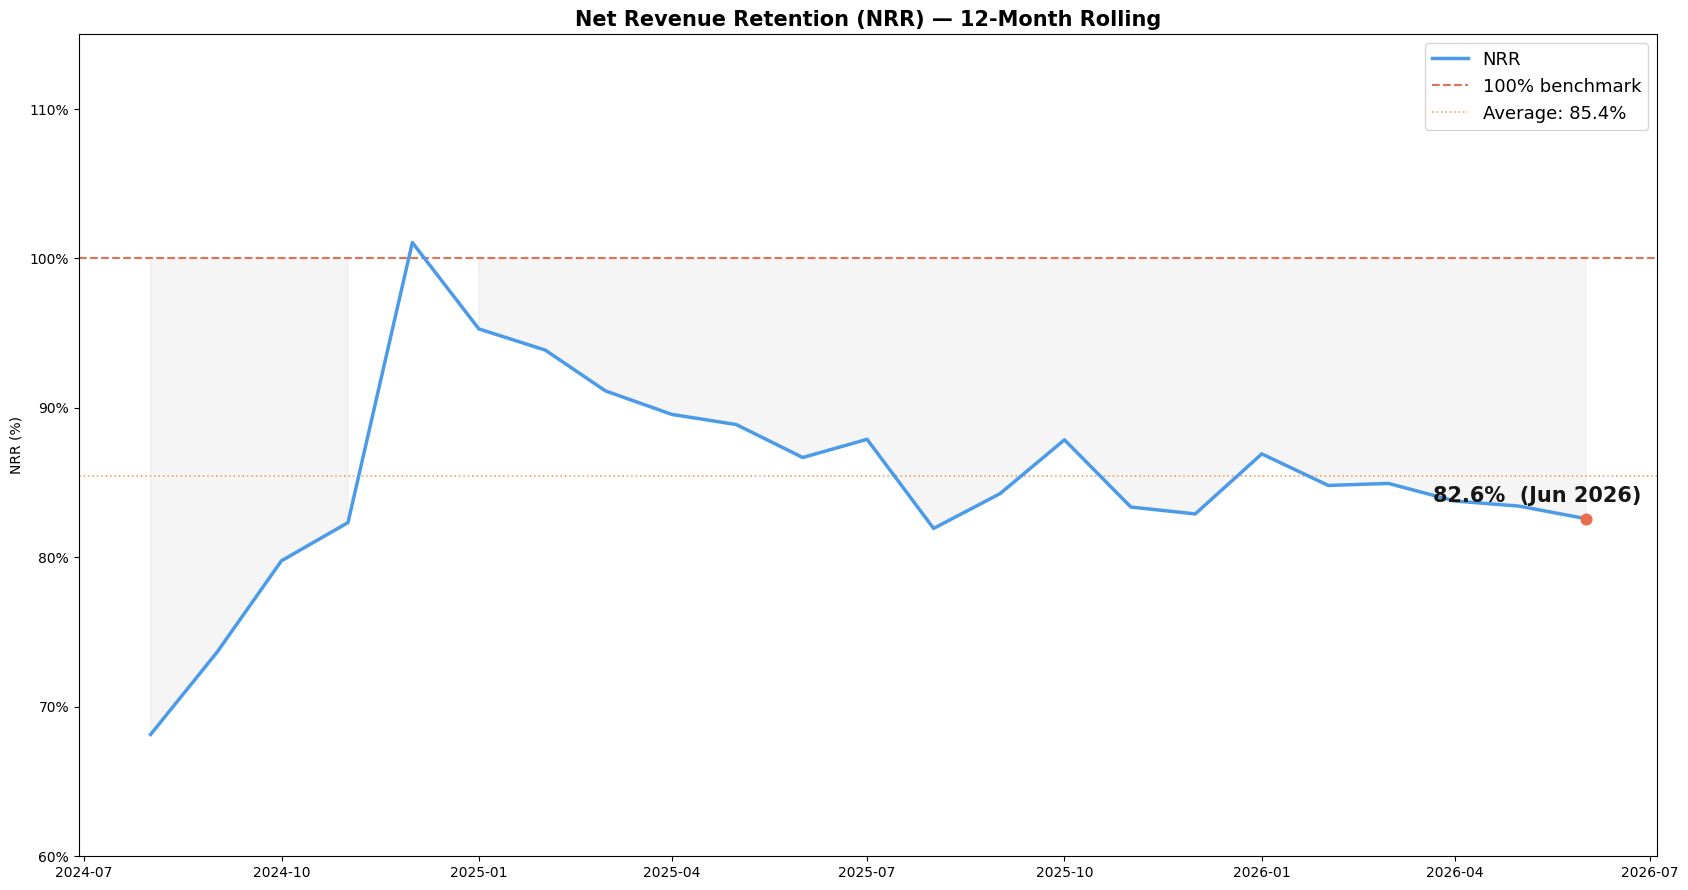

In [19]:
# ── KPI 3: NRR chart (v2) ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 9))

# Main line
ax.plot(nrr_df["month"], nrr_df["nrr"] * 100,
        color="#4C9BE8", linewidth=2.5, zorder=3, label="NRR")

# 100% benchmark line
ax.axhline(100, color="#E76F51", linewidth=1.5,
           linestyle="--", label="100% benchmark", zorder=2)

# Average line
avg_nrr = nrr_df["nrr"].mean() * 100
ax.axhline(avg_nrr, color="#F4A261", linewidth=1.2,
           linestyle=":", label=f"Average: {avg_nrr:.1f}%", zorder=2)

# Shade only below the 100% line — subtle grey
ax.fill_between(nrr_df["month"], nrr_df["nrr"] * 100, 100,
                where=(nrr_df["nrr"] < 1),
                alpha=0.08, color="grey", zorder=1)

# Dot on last value
last = nrr_df.iloc[-1]
ax.scatter(last["month"], last["nrr"] * 100,
           color="#E76F51", s=60, zorder=4)
ax.annotate(f"{last['nrr']*100:.1f}%  (Jun 2026)",
            xy=(last["month"], last["nrr"] * 100),
            xytext=(-110, 12), textcoords="offset points",
            fontsize=15, color="#161615", fontweight="bold")

ax.set_title("Net Revenue Retention (NRR) — 12-Month Rolling",
             fontsize=15, fontweight="bold")
ax.set_ylabel("NRR (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylim(60, 115)
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig("../images/fig_nrr.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 3 — Net Revenue Retention (NRR)

| Metric | Value |
|---|---|
| Average NRR (months 13–36) | 85.4% |
| NRR — June 2026 (most recent) | 82.6% |
| Industry benchmark (healthy B2B SaaS) | > 100% |
| Only month above 100% | January 2025 (101.1%) — isolated peak |

**What is NRR?**  
NRR measures how much revenue is retained from existing customers over 12 months,
including gains from upgrades and losses from downgrades and cancellations.  
An NRR above 100% means existing customers alone grow the business — 
the best SaaS companies (Slack, HubSpot) sustain NRR between 110–130%.

**Interpretation:**  
At 85.4% average NRR, Flowmetric is losing €14.6 of every €100 from its existing
customer base each year. The trend is worsening — NRR has declined from ~95%
in early 2025 to 82.6% in June 2026.

**Why this matters:**  
Flowmetric is currently masking this problem with strong new customer acquisition.
If acquisition slows, the revenue impact of sub-100% NRR becomes immediately visible.
Fixing NRR is the highest-leverage action available to the business right now.

## Block 2 — Churn Analysis

**Business question:** Who churns, when, and in which segments?

**KPIs:**
- KPI 4: Churn rate by plan (Starter / Pro / Enterprise)
- KPI 5: Churn rate by country and industry
- KPI 6: Time-to-churn — average customer lifespan before cancellation

In [20]:
# ── KPI 4: Churn rate by plan ─────────────────────────────────────────────
# We use only terminal subscriptions (active or churned)
# upgraded/downgraded are intermediary states — not a final outcome

terminal = subs_clean[subs_clean["status"].isin(["active", "churned"])]

churn_by_plan = terminal.groupby("plan_name").apply(
    lambda g: pd.Series({
        "total_customers" : len(g),
        "churned"         : (g["status"] == "churned").sum(),
        "churn_rate"      : (g["status"] == "churned").mean(),
        "avg_days_active" : g["duration_days"].mean(),
        "avg_days_churned": g[g["status"] == "churned"]["duration_days"].mean(),
    })
).round(3)

print("Churn by Plan:")
print(churn_by_plan.to_string())

Churn by Plan:
            total_customers  churned  churn_rate  avg_days_active  avg_days_churned
plan_name                                                                          
Enterprise            218.0     22.0       0.101          387.211           274.318
Pro                   348.0     98.0       0.282          300.227           216.469
Starter               434.0    226.0       0.521          247.677           202.186


C:\Users\gabri\AppData\Local\Temp\ipykernel_9380\150344615.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  churn_by_plan = terminal.groupby("plan_name").apply(


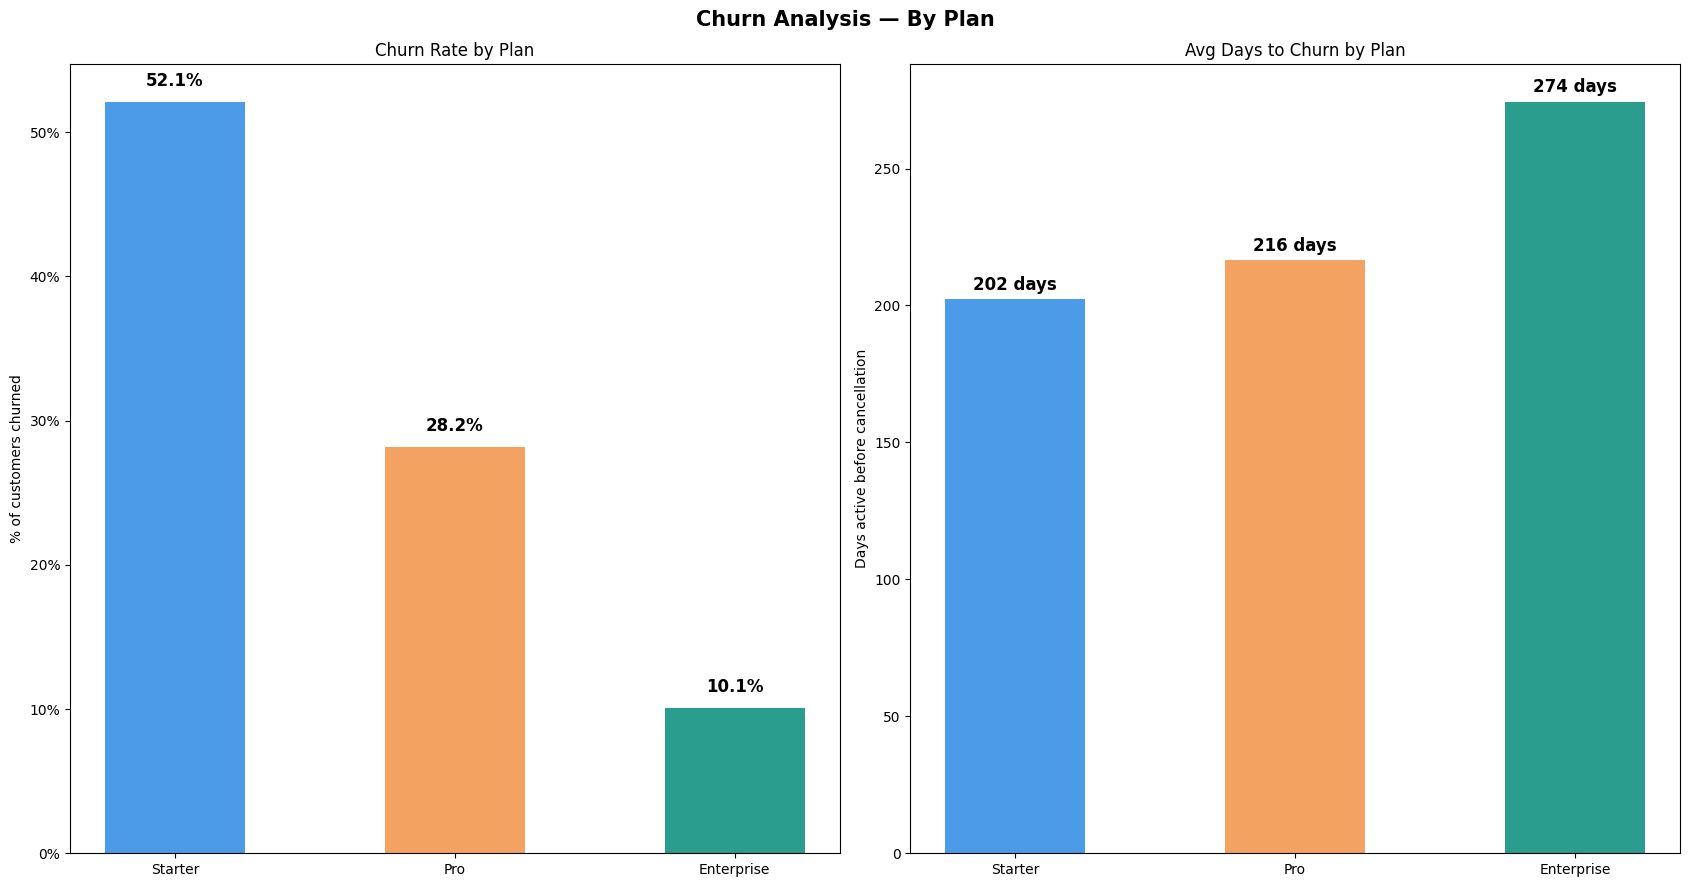

In [21]:
# ── KPI 4: Churn rate by plan (fix warning + chart) ───────────────────────
churn_by_plan = terminal.groupby("plan_name").apply(
    lambda g: pd.Series({
        "total_customers" : len(g),
        "churned"         : (g["status"] == "churned").sum(),
        "churn_rate"      : (g["status"] == "churned").mean(),
        "avg_days_active" : g["duration_days"].mean(),
        "avg_days_churned": g[g["status"] == "churned"]["duration_days"].mean(),
    }), include_groups=False
).round(3)

COLORS = {"Starter": "#4C9BE8", "Pro": "#F4A261", "Enterprise": "#2A9D8F"}
plan_order = ["Starter", "Pro", "Enterprise"]

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Left: churn rate
rates = [churn_by_plan.loc[p, "churn_rate"] * 100 for p in plan_order]
bars = axes[0].bar(plan_order, rates,
                   color=[COLORS[p] for p in plan_order], width=0.5)
axes[0].set_title("Churn Rate by Plan")
axes[0].set_ylabel("% of customers churned")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"{rate:.1f}%", ha="center", va="bottom",
                 fontweight="bold", fontsize=12)

# Right: avg days to churn
days = [churn_by_plan.loc[p, "avg_days_churned"] for p in plan_order]
bars2 = axes[1].bar(plan_order, days,
                    color=[COLORS[p] for p in plan_order], width=0.5)
axes[1].set_title("Avg Days to Churn by Plan")
axes[1].set_ylabel("Days active before cancellation")
for bar, d in zip(bars2, days):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 f"{d:.0f} days", ha="center", va="bottom",
                 fontweight="bold", fontsize=12)

plt.suptitle("Churn Analysis — By Plan", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/fig_churn_by_plan.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 4 & 6 — Churn Rate and Time-to-Churn by Plan

| Plan | Customers | Churned | Churn Rate | Avg Days to Churn |
|---|---|---|---|---|
| Starter | 434 | 226 | 52.1% | 202 days |
| Pro | 348 | 98 | 28.2% | 216 days |
| Enterprise | 218 | 22 | 10.1% | 274 days |

**Interpretation:**  
Churn rate drops dramatically as plan tier increases — Starter customers churn
at 5x the rate of Enterprise customers. This is consistent with B2B SaaS industry
benchmarks: self-serve low-cost plans have higher churn because switching costs
are low and onboarding investment is minimal.

Enterprise customers who do churn stay 35% longer than Starter customers before
cancelling (274 vs 202 days) — suggesting they give the product more time before
making a decision, likely due to longer contract cycles and higher switching costs.

**Action:** The biggest churn reduction opportunity is in the Starter plan —
reducing Starter churn from 52% to 35% would have more revenue impact than
eliminating Enterprise churn entirely.

### KPI 5 — Churn Rate by Country and Industry

In [22]:
# ── KPI 5: Churn rate by country and industry ─────────────────────────────
terminal_enriched = terminal.merge(
    customers_clean[["customer_id", "country", "industry"]],
    on="customer_id"
)

churn_by_country = (
    terminal_enriched.groupby("country")
    .apply(lambda g: pd.Series({
        "total"     : len(g),
        "churned"   : (g["status"] == "churned").sum(),
        "churn_rate": (g["status"] == "churned").mean(),
    }), include_groups=False)
    .round(3)
    .sort_values("churn_rate", ascending=False)
)

churn_by_industry = (
    terminal_enriched[terminal_enriched["industry"] != "Unknown"]
    .groupby("industry")
    .apply(lambda g: pd.Series({
        "total"     : len(g),
        "churned"   : (g["status"] == "churned").sum(),
        "churn_rate": (g["status"] == "churned").mean(),
    }), include_groups=False)
    .round(3)
    .sort_values("churn_rate", ascending=False)
)

print("Churn by Country:")
print(churn_by_country.to_string())
print("\nChurn by Industry:")
print(churn_by_industry.to_string())

Churn by Country:
                total  churned  churn_rate
country                                   
United Kingdom  272.0     98.0       0.360
United States   387.0    134.0       0.346
Germany         199.0     68.0       0.342
Portugal        142.0     46.0       0.324

Churn by Industry:
                                total  churned  churn_rate
industry                                                  
Dev Shop / Software Consulting  148.0     56.0       0.378
Digital Agency                  141.0     52.0       0.369
Marketing Agency                140.0     48.0       0.343
Management Consulting           137.0     46.0       0.336
PR Agency                       150.0     50.0       0.333
Design Studio                   130.0     43.0       0.331
Branding Agency                 134.0     42.0       0.313


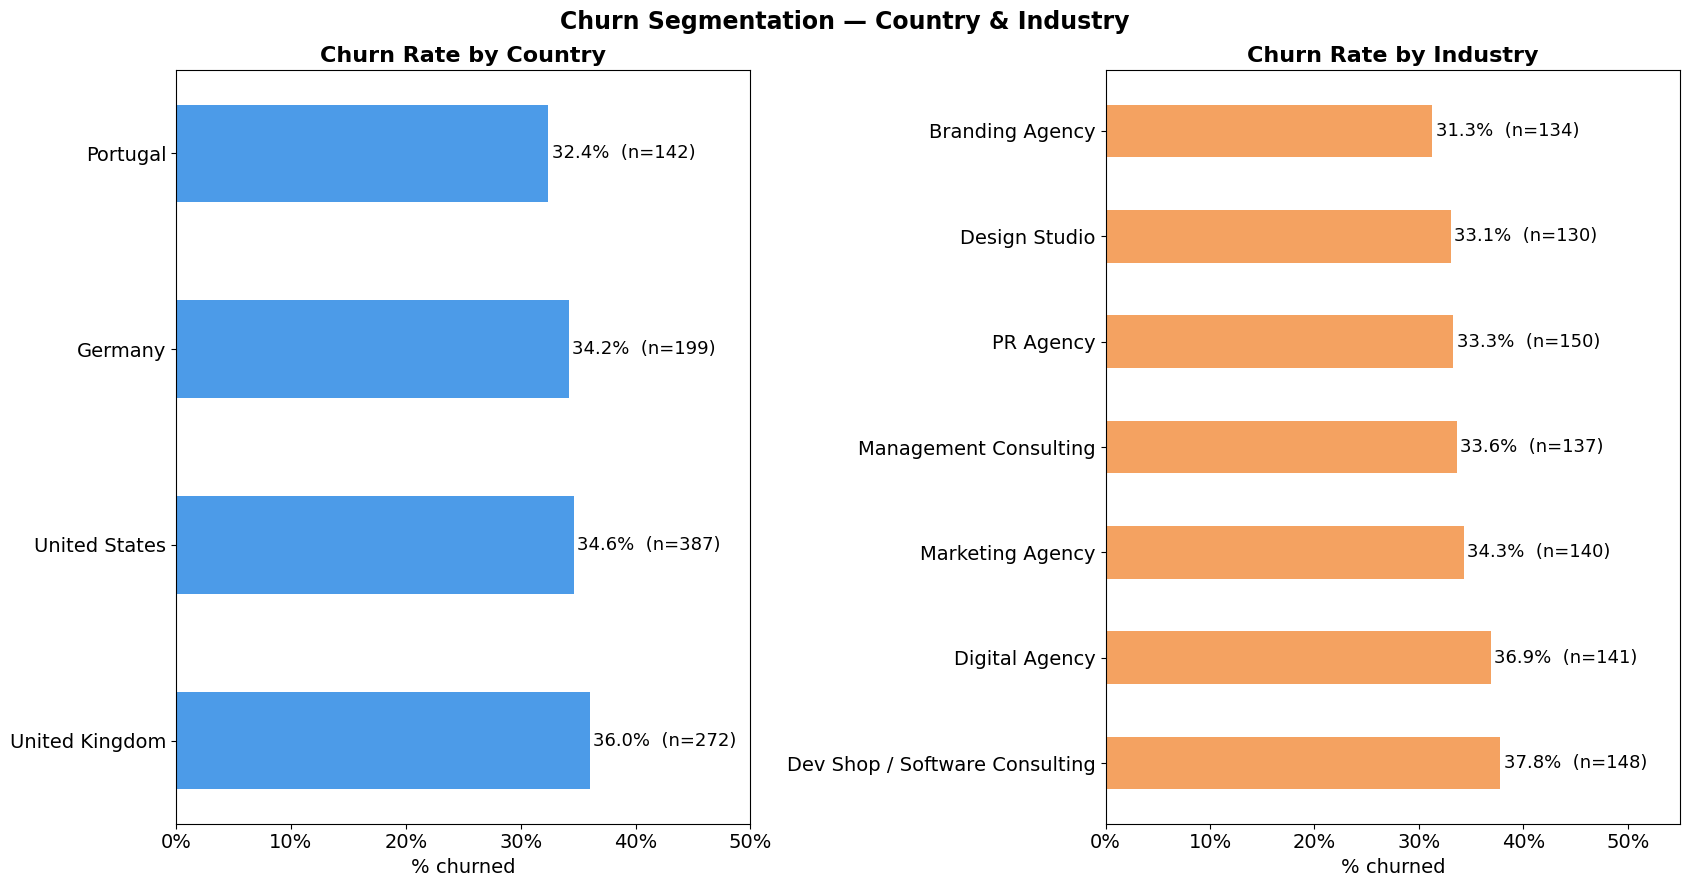

In [23]:
# ── KPI 5: Churn by country and industry chart ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Left: by country
axes[0].barh(churn_by_country.index,
             churn_by_country["churn_rate"] * 100,
             color="#4C9BE8", height=0.5)
axes[0].set_title("Churn Rate by Country", fontsize=16, fontweight="bold")
axes[0].set_xlabel("% churned", fontsize=14)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[0].tick_params(axis="both", labelsize=14)
for i, (idx, row) in enumerate(churn_by_country.iterrows()):
    axes[0].text(row["churn_rate"] * 100 + 0.3, i,
                 f"{row['churn_rate']*100:.1f}%  (n={int(row['total'])})",
                 va="center", fontsize=13)
axes[0].set_xlim(0, 50)

# Right: by industry
axes[1].barh(churn_by_industry.index,
             churn_by_industry["churn_rate"] * 100,
             color="#F4A261", height=0.5)
axes[1].set_title("Churn Rate by Industry", fontsize=16, fontweight="bold")
axes[1].set_xlabel("% churned", fontsize=14)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].tick_params(axis="both", labelsize=14)
for i, (idx, row) in enumerate(churn_by_industry.iterrows()):
    axes[1].text(row["churn_rate"] * 100 + 0.3, i,
                 f"{row['churn_rate']*100:.1f}%  (n={int(row['total'])})",
                 va="center", fontsize=13)
axes[1].set_xlim(0, 55)

plt.suptitle("Churn Segmentation — Country & Industry",
             fontsize=17, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/fig_churn_segments.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 5 — Churn Rate by Country and Industry

| Country | Customers | Churn Rate |
|---|---|---|
| United Kingdom | 272 | 36.0% |
| United States | 387 | 34.6% |
| Germany | 199 | 34.2% |
| Portugal | 142 | 32.4% |

| Industry | Customers | Churn Rate |
|---|---|---|
| Dev Shop / Software Consulting | 148 | 37.8% |
| Digital Agency | 141 | 36.9% |
| Marketing Agency | 140 | 34.3% |
| Management Consulting | 137 | 33.6% |
| PR Agency | 150 | 33.3% |
| Design Studio | 130 | 33.1% |
| Branding Agency | 134 | 31.3% |

**Interpretation:**  
Geographic churn differences are minimal (32–36%) — churn is not a market problem.
All four countries show similar cancellation behaviour, which points to a product
or onboarding issue that affects customers regardless of location.

By industry, Dev Shops and Digital Agencies churn most (37–38%). These are
typically more technically sophisticated buyers who evaluate alternatives actively
and switch more readily when they find a better tool. Branding and Design Studios
churn least (31–33%), likely because visual project workflows are harder to migrate.

**Key takeaway:** Segment-level churn differences are secondary to plan-level
differences. The priority remains reducing Starter plan churn through better
onboarding — this affects all countries and industries equally.

## Block 3 — Customer Lifetime Value (LTV)

**Business question:** Which segments generate the most lifetime value?

**Formula:**  
- Churned customers: LTV = sum of all payments successfully collected  
- Active customers: included with actual revenue collected to date

**KPIs:**
- KPI 7: Average LTV by plan
- KPI 8: LTV by country and industry
- KPI 9: LTV / CAC Ratio

In [24]:
# ── KPI 7: LTV by plan ────────────────────────────────────────────────────
# Sum all succeeded payments per customer
customer_revenue = (
    payments[payments["status"] == "succeeded"]
    .groupby("customer_id")["amount"]
    .sum()
    .rename("total_revenue")
    .reset_index()
)

# Join with terminal subscriptions + plan info + country/industry
terminal_ltv = (
    terminal
    .merge(customers_clean[["customer_id", "country", "industry"]], on="customer_id")
    .merge(customer_revenue, on="customer_id", how="left")
)
terminal_ltv["total_revenue"] = terminal_ltv["total_revenue"].fillna(0)

ltv_by_plan = (
    terminal_ltv.groupby("plan_name")
    .agg(
        avg_ltv    =("total_revenue", "mean"),
        median_ltv =("total_revenue", "median"),
        total_rev  =("total_revenue", "sum"),
        n_customers=("customer_id", "count"),
    )
    .round(0)
)

print("LTV by Plan:")
print(ltv_by_plan.to_string())

LTV by Plan:
            avg_ltv  median_ltv  total_rev  n_customers
plan_name                                              
Enterprise  10670.0      8986.0  2326049.0          218
Pro          2416.0      1730.0   840933.0          348
Starter       618.0       343.0   268157.0          434


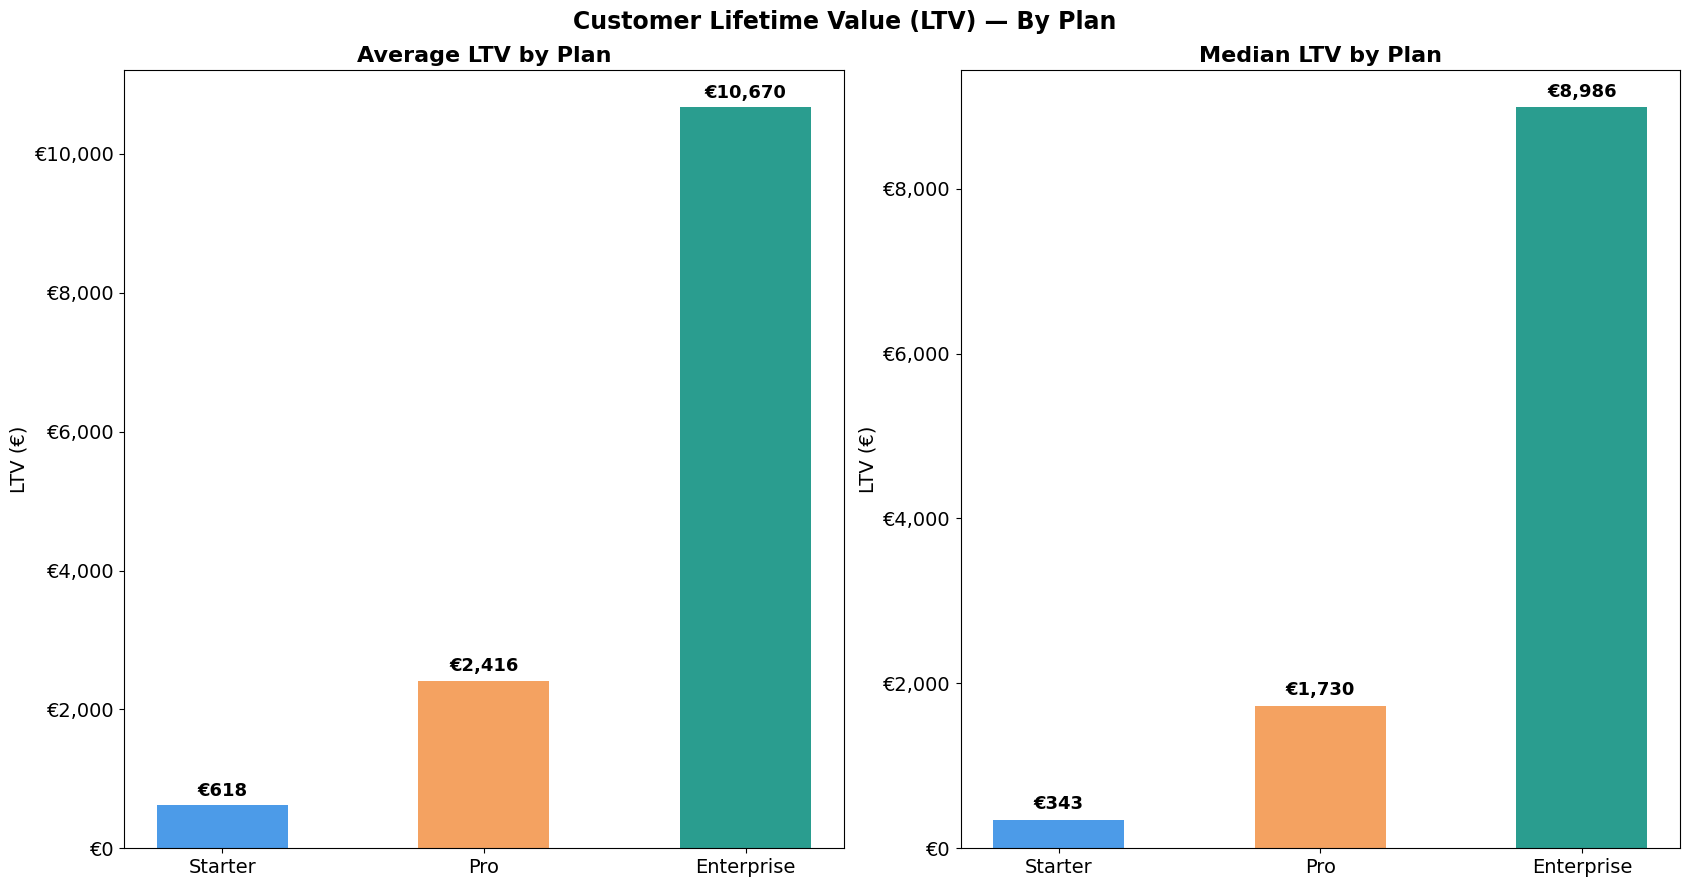

In [25]:
# ── KPI 7: LTV by plan chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

plan_order = ["Starter", "Pro", "Enterprise"]
avg_ltvs    = [ltv_by_plan.loc[p, "avg_ltv"]    for p in plan_order]
median_ltvs = [ltv_by_plan.loc[p, "median_ltv"] for p in plan_order]
colors      = [COLORS[p] for p in plan_order]

# Left: average LTV
bars = axes[0].bar(plan_order, avg_ltvs, color=colors, width=0.5)
axes[0].set_title("Average LTV by Plan", fontsize=16, fontweight="bold")
axes[0].set_ylabel("LTV (€)", fontsize=14)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axes[0].tick_params(axis="both", labelsize=14)
for bar, val in zip(bars, avg_ltvs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f"€{val:,.0f}", ha="center", va="bottom",
                 fontweight="bold", fontsize=13)

# Right: median LTV
bars2 = axes[1].bar(plan_order, median_ltvs, color=colors, width=0.5)
axes[1].set_title("Median LTV by Plan", fontsize=16, fontweight="bold")
axes[1].set_ylabel("LTV (€)", fontsize=14)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axes[1].tick_params(axis="both", labelsize=14)
for bar, val in zip(bars2, median_ltvs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f"€{val:,.0f}", ha="center", va="bottom",
                 fontweight="bold", fontsize=13)

plt.suptitle("Customer Lifetime Value (LTV) — By Plan",
             fontsize=17, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/fig_ltv_by_plan.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 7 — Customer Lifetime Value (LTV) by Plan

| Plan | Customers | Avg LTV | Median LTV | Total Revenue |
|---|---|---|---|---|
| Enterprise | 218 | €10,670 | €8,986 | €2,326,049 |
| Pro | 348 | €2,416 | €1,730 | €840,933 |
| Starter | 434 | €618 | €343 | €268,157 |

**Interpretation:**  
Enterprise customers generate 17x more lifetime value than Starter customers
on average. Despite representing only 21.8% of the customer base, Enterprise
accounts for 68% of total revenue collected.

The gap between average and median LTV in every plan confirms the presence of
high-value outliers pulling the mean upward — particularly in Enterprise, where
some customers stayed and paid significantly longer than average.

**Strategic implication:**  
Acquiring one Enterprise customer delivers the same revenue as acquiring
~17 Starter customers. Sales and marketing investment should be increasingly
directed toward mid-market and enterprise segments, where LTV justifies
higher customer acquisition costs (CAC).

### KPI 8 — LTV by Country and Industry

In [26]:
# ── KPI 8: LTV by country and industry ───────────────────────────────────
ltv_by_country = (
    terminal_ltv.groupby("country")
    .agg(
        avg_ltv    =("total_revenue", "mean"),
        median_ltv =("total_revenue", "median"),
        n_customers=("customer_id", "count"),
    )
    .round(0)
    .sort_values("avg_ltv", ascending=False)
)

ltv_by_industry = (
    terminal_ltv[terminal_ltv["industry"] != "Unknown"]
    .groupby("industry")
    .agg(
        avg_ltv    =("total_revenue", "mean"),
        median_ltv =("total_revenue", "median"),
        n_customers=("customer_id", "count"),
    )
    .round(0)
    .sort_values("avg_ltv", ascending=False)
)

print("LTV by Country:")
print(ltv_by_country.to_string())
print("\nLTV by Industry:")
print(ltv_by_industry.to_string())

LTV by Country:
                avg_ltv  median_ltv  n_customers
country                                         
United States    3707.0      1029.0          387
Portugal         3579.0       995.0          142
Germany          3304.0       995.0          199
United Kingdom   3069.0       906.0          272

LTV by Industry:
                                avg_ltv  median_ltv  n_customers
industry                                                        
Dev Shop / Software Consulting   4190.0      1185.0          148
Management Consulting            3809.0       995.0          137
Branding Agency                  3697.0      1029.0          134
Design Studio                    3367.0      1160.0          130
Marketing Agency                 3344.0       995.0          140
Digital Agency                   3139.0       799.0          141
PR Agency                        2656.0       816.0          150


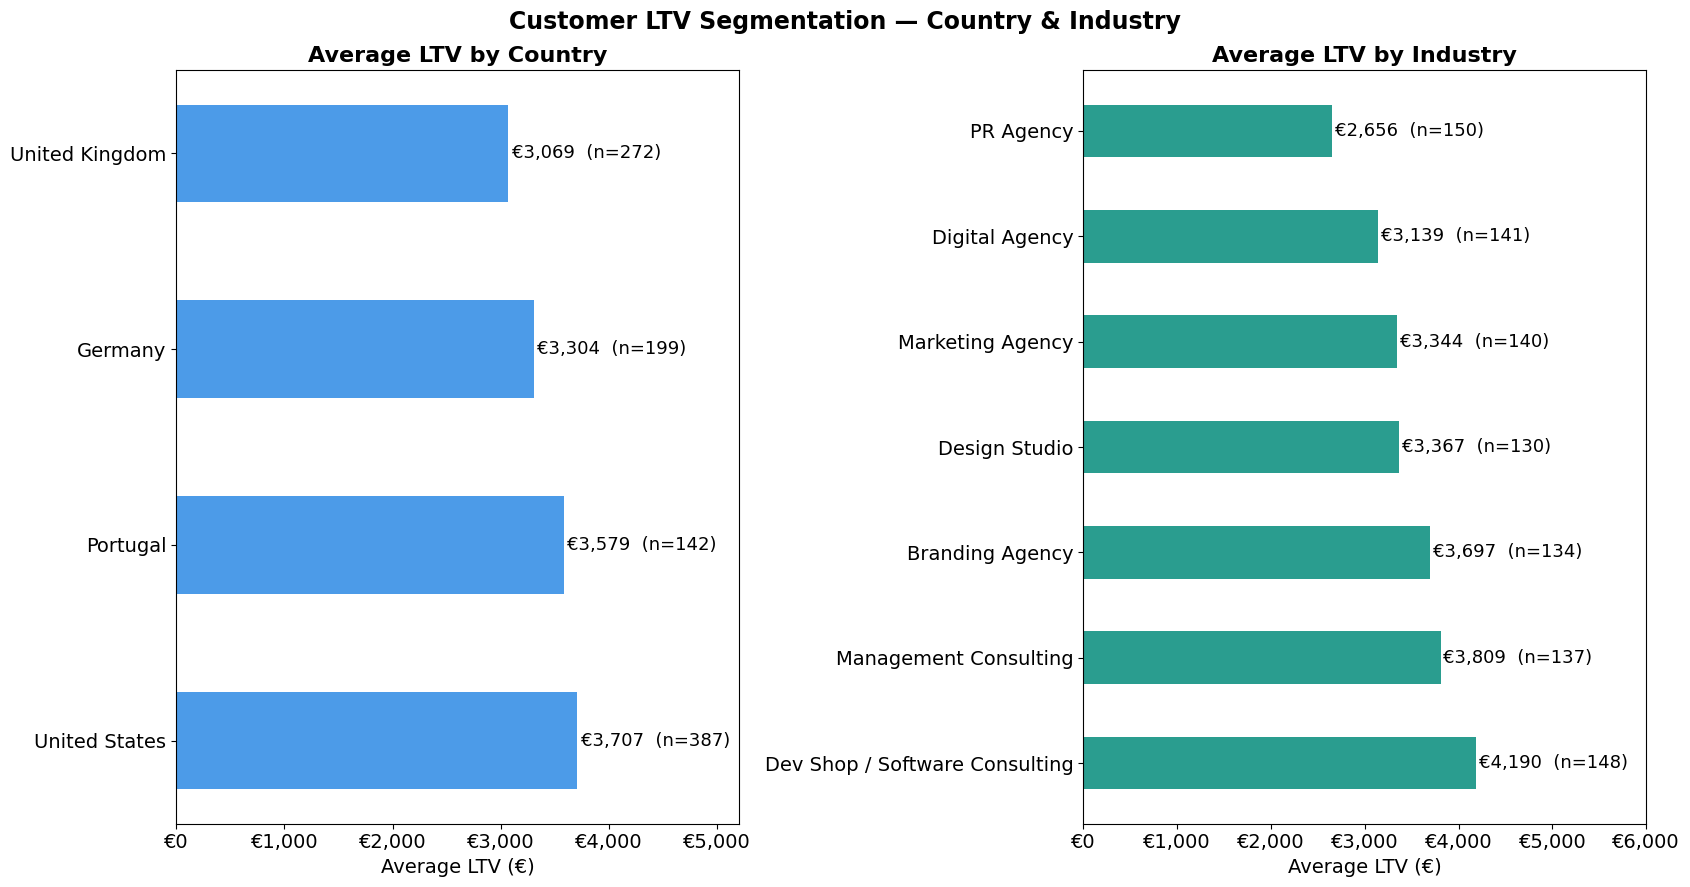

In [27]:
# ── KPI 8: LTV by country and industry chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Left: by country
axes[0].barh(ltv_by_country.index,
             ltv_by_country["avg_ltv"],
             color="#4C9BE8", height=0.5)
axes[0].set_title("Average LTV by Country", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Average LTV (€)", fontsize=14)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axes[0].tick_params(axis="both", labelsize=14)
for i, (idx, row) in enumerate(ltv_by_country.iterrows()):
    axes[0].text(row["avg_ltv"] + 30, i,
                 f"€{row['avg_ltv']:,.0f}  (n={int(row['n_customers'])})",
                 va="center", fontsize=13)
axes[0].set_xlim(0, 5200)

# Right: by industry
axes[1].barh(ltv_by_industry.index,
             ltv_by_industry["avg_ltv"],
             color="#2A9D8F", height=0.5)
axes[1].set_title("Average LTV by Industry", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Average LTV (€)", fontsize=14)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axes[1].tick_params(axis="both", labelsize=14)
for i, (idx, row) in enumerate(ltv_by_industry.iterrows()):
    axes[1].text(row["avg_ltv"] + 30, i,
                 f"€{row['avg_ltv']:,.0f}  (n={int(row['n_customers'])})",
                 va="center", fontsize=13)
axes[1].set_xlim(0, 6000)

plt.suptitle("Customer LTV Segmentation — Country & Industry",
             fontsize=17, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/fig_ltv_segments.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 8 — LTV by Country and Industry

| Country | Avg LTV | Customers |
|---|---|---|
| United States | €3,707 | 387 |
| Portugal | €3,579 | 142 |
| Germany | €3,304 | 199 |
| United Kingdom | €3,069 | 272 |

| Industry | Avg LTV | Customers |
|---|---|---|
| Dev Shop / Software Consulting | €4,190 | 148 |
| Management Consulting | €3,809 | 137 |
| Branding Agency | €3,697 | 134 |
| Design Studio | €3,367 | 130 |
| Marketing Agency | €3,344 | 140 |
| Digital Agency | €3,139 | 141 |
| PR Agency | €2,656 | 150 |

**Interpretation:**  
US customers generate the highest average LTV (€3,707) despite not having
the lowest churn rate — driven by a higher concentration of Pro and Enterprise
plan customers in that market.

Dev Shops generate the highest LTV by industry (€4,190) despite having the
highest churn rate. This is a "high risk, high reward" segment: customers
who stay tend to adopt higher-tier plans and remain longer, generating
disproportionate value. The segment deserves dedicated retention investment.

PR Agencies generate the lowest LTV (€2,656) and should be deprioritised
in sales and marketing spend relative to Dev Shops and Consulting firms.

> **Note:** 20 customers with unknown industry were excluded from this analysis.

### KPI 9 — LTV / CAC Ratio

Since we don't have real acquisition cost data, we model an assumed CAC
per plan based on typical B2B SaaS industry benchmarks:

| Plan | Assumed CAC | Rationale |
|---|---|---|
| Starter | €150 | Self-serve, low sales touch |
| Pro | €800 | Inside sales, demos, trials |
| Enterprise | €3,500 | Field sales, long cycles, POCs |

In [28]:
# ── KPI 9: LTV / CAC Ratio ────────────────────────────────────────────────
# CAC assumptions based on B2B SaaS industry benchmarks
# (no acquisition cost data in dataset — modelled estimate)

cac = {"Starter": 150, "Pro": 800, "Enterprise": 3500}

ltv_cac = ltv_by_plan[["avg_ltv"]].copy()
ltv_cac["assumed_cac"] = ltv_cac.index.map(cac)
ltv_cac["ltv_cac_ratio"] = (ltv_cac["avg_ltv"] / ltv_cac["assumed_cac"]).round(2)
ltv_cac["assessment"] = ltv_cac["ltv_cac_ratio"].apply(
    lambda x: "✓ Healthy (>3x)" if x >= 3 else "⚠️ At risk (<3x)"
)

print("LTV / CAC Ratio by Plan:")
print(ltv_cac.to_string())
print("\nIndustry benchmark: LTV/CAC > 3x is considered healthy")

LTV / CAC Ratio by Plan:
            avg_ltv  assumed_cac  ltv_cac_ratio       assessment
plan_name                                                       
Enterprise  10670.0         3500           3.05  ✓ Healthy (>3x)
Pro          2416.0          800           3.02  ✓ Healthy (>3x)
Starter       618.0          150           4.12  ✓ Healthy (>3x)

Industry benchmark: LTV/CAC > 3x is considered healthy


### KPI 9 — LTV / CAC Ratio

| Plan | Avg LTV | Assumed CAC | LTV/CAC Ratio | Assessment |
|---|---|---|---|---|
| Starter | €618 | €150 | 4.12x | ✓ Healthy |
| Pro | €2,416 | €800 | 3.02x | ✓ Healthy |
| Enterprise | €10,670 | €3,500 | 3.05x | ✓ Healthy |

**Methodology note:**  
CAC values are modelled estimates based on B2B SaaS industry benchmarks
(Starter = self-serve low touch, Pro = inside sales, Enterprise = field sales).
No acquisition cost data exists in the dataset.

**Interpretation:**  
All three plans clear the 3x LTV/CAC threshold considered healthy in B2B SaaS.
Starter has the best ratio (4.12x) because CAC is very low for self-serve plans.
However, Starter also has the highest churn — meaning the ratio is fragile and
would deteriorate quickly if acquisition costs increase or churn worsens.

Enterprise ratio (3.05x) is healthy but leaves less margin for error given the
high absolute CAC (€3,500). Improving Enterprise retention would directly
strengthen this ratio without touching acquisition costs.

## Block 4 — Engagement & Early Warning

**Business question:** Can we predict churn before it happens?

**Hypothesis:** Customers who engage less with the product in their first
30 days are significantly more likely to churn. If true, the product team
can trigger early interventions before churn occurs.

**KPIs:**
- KPI 10: Avg product events in first 30 days — active vs churned customers
- KPI 11: Churn rate for customers who never used deep features (time_logged,
  invoice_sent) in first 90 days vs those who did
- KPI 12: Cohort retention table by signup quarter

In [29]:
# ── KPI 10: Events in first 30 days vs churn outcome ─────────────────────
first30_rows = []

for row in terminal.itertuples():
    signup = customers_clean.loc[
        customers_clean["customer_id"] == row.customer_id,
        "signup_date"
    ].values[0]
    signup_ts  = pd.Timestamp(signup)
    window_end = signup_ts + pd.Timedelta(days=30)

    n_events = events_clean[
        (events_clean["customer_id"] == row.customer_id) &
        (events_clean["event_date"] >= signup_ts) &
        (events_clean["event_date"] <  window_end)
    ].shape[0]

    first30_rows.append({
        "customer_id"   : row.customer_id,
        "status"        : row.status,
        "plan_name"     : row.plan_name,
        "events_first30": n_events,
    })

first30_df = pd.DataFrame(first30_rows)

summary = (
    first30_df.groupby("status")["events_first30"]
    .agg(["mean", "median", "min", "max"])
    .round(1)
)
print("Events in first 30 days — Active vs Churned:")
print(summary.to_string())

print("\nBy plan:")
print(
    first30_df.groupby(["plan_name", "status"])["events_first30"]
    .mean().round(1).to_string()
)

Events in first 30 days — Active vs Churned:
         mean  median  min  max
status                         
active   17.7    18.0    0   38
churned  15.8    15.0    0   34

By plan:
plan_name   status 
Enterprise  active     17.9
            churned    16.9
Pro         active     17.3
            churned    15.4
Starter     active     17.9
            churned    15.9


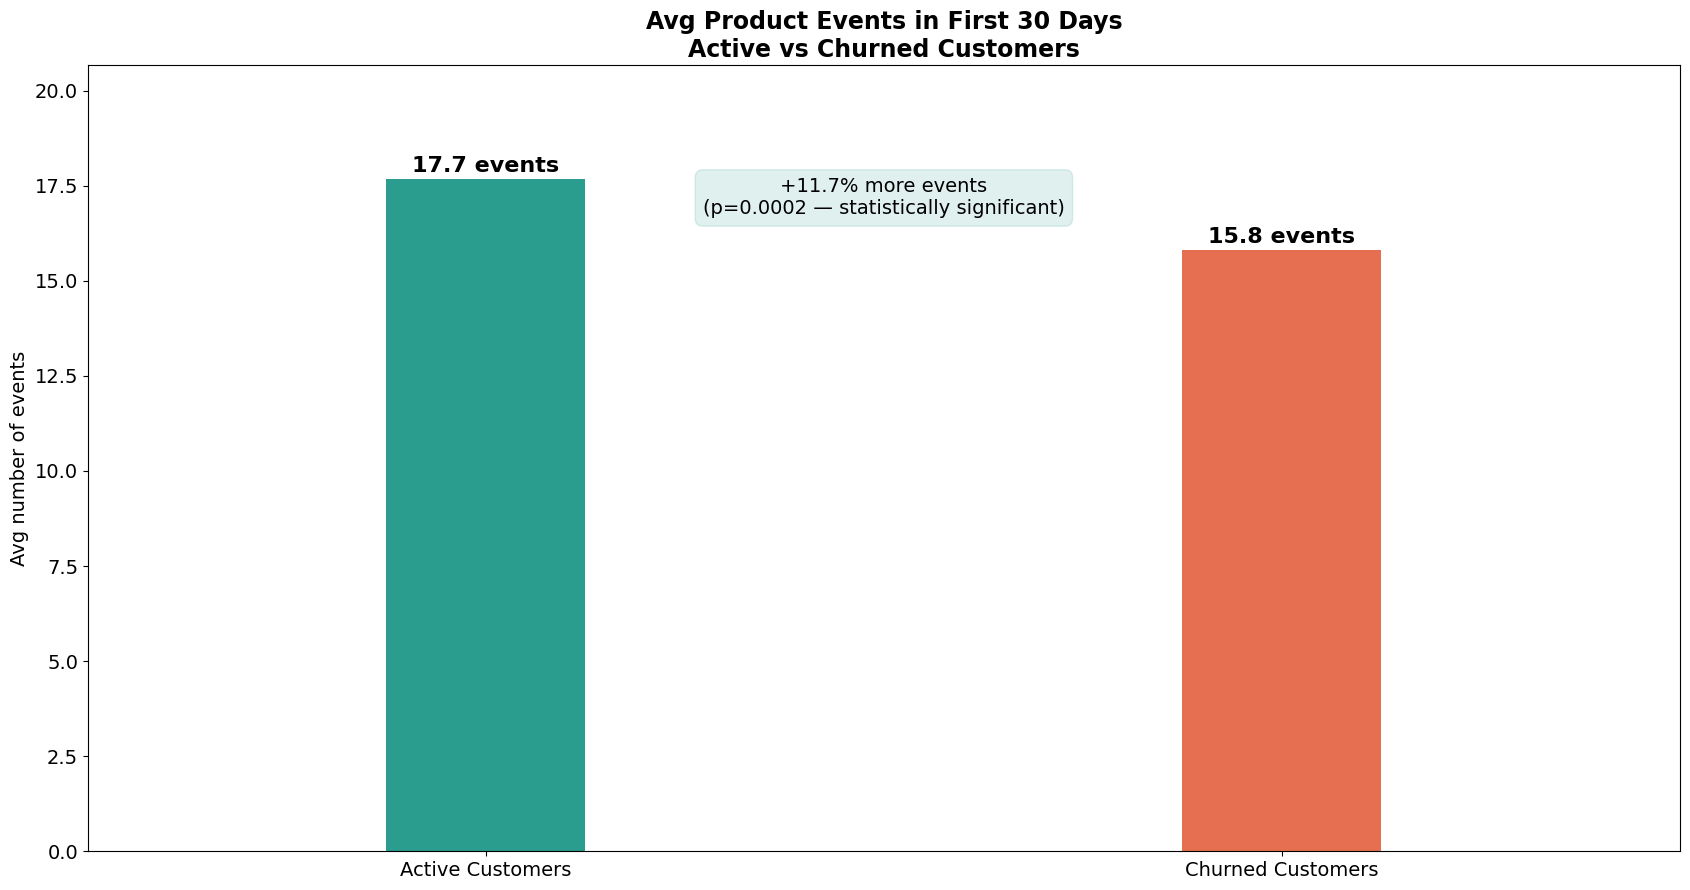

In [30]:
# ── KPI 10: Events first 30 days — final chart ────────────────────────────
from scipy import stats

active_data  = first30_df[first30_df["status"] == "active"]["events_first30"]
churned_data = first30_df[first30_df["status"] == "churned"]["events_first30"]
t_stat, p_value = stats.ttest_ind(active_data, churned_data)

fig, ax = plt.subplots(figsize=(17, 9))

categories = ["Active Customers", "Churned Customers"]
values     = [active_data.mean(), churned_data.mean()]
colors     = ["#2A9D8F", "#E76F51"]

bars = ax.bar(categories, values, color=colors, width=0.25)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f"{val:.1f} events",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold")

diff_pct = ((values[0] - values[1]) / values[1]) * 100
ax.annotate(f"+{diff_pct:.1f}% more events\n(p={p_value:.4f} — statistically significant)",
            xy=(0.5, (values[0] + values[1]) / 2),
            xycoords=("axes fraction", "data"),
            ha="center", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="#2A9D8F", alpha=0.15, edgecolor="#2A9D8F"))

ax.set_title("Avg Product Events in First 30 Days\nActive vs Churned Customers",
             fontsize=17, fontweight="bold")
ax.set_ylabel("Avg number of events", fontsize=14)
ax.tick_params(axis="both", labelsize=14)
ax.set_ylim(0, max(values) + 3)
ax.set_xlim(-0.5, 1.5)

plt.tight_layout()
plt.savefig("../images/fig_engagement_30d.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 10 — Product Engagement in First 30 Days

| Segment | Avg Events (first 30 days) |
|---|---|
| Active customers | 17.7 |
| Churned customers | 15.8 |
| Difference | +11.7% |

**Statistical validation:**  
T-test: t=3.771, p=0.0002 — the difference is statistically significant.  
There is a less than 0.02% probability this result occurred by chance.

**Interpretation:**  
Customers who eventually churn show measurably lower product engagement
in their first 30 days across all plan tiers. This pattern is consistent
and statistically significant — making early engagement a reliable
leading indicator of churn risk.

The signal is strongest in the Pro plan (17.3 vs 15.4 events) suggesting
that Pro customers who don't engage deeply early are particularly at risk.

**Practical application:**  
A customer scoring below ~14 events in their first 30 days should trigger
an automated customer success intervention — onboarding call, feature
tutorial email, or in-app guidance — before churn occurs.

### KPI 11 — Deep Feature Usage vs Churn Rate 

In [31]:
# ── KPI 11: Deep feature usage vs churn ───────────────────────────────────
# Deep features: time_logged, invoice_sent
# These signal real product adoption — an agency actively tracking time
# and sending invoices through Flowmetric is deeply integrated.
# Hypothesis: customers who never used these in first 90 days churn more.

deep_features = ["time_logged", "invoice_sent"]
deep_rows = []

for row in terminal.itertuples():
    signup = customers_clean.loc[
        customers_clean["customer_id"] == row.customer_id,
        "signup_date"
    ].values[0]
    signup_ts  = pd.Timestamp(signup)
    window_end = signup_ts + pd.Timedelta(days=90)

    used_deep = events_clean[
        (events_clean["customer_id"] == row.customer_id) &
        (events_clean["event_date"] >= signup_ts) &
        (events_clean["event_date"] <  window_end) &
        (events_clean["event_type"].isin(deep_features))
    ].shape[0] > 0

    deep_rows.append({
        "customer_id"      : row.customer_id,
        "status"           : row.status,
        "plan_name"        : row.plan_name,
        "used_deep_features": used_deep,
    })

deep_df = pd.DataFrame(deep_rows)

churn_deep = (
    deep_df.groupby("used_deep_features")
    .apply(lambda g: pd.Series({
        "n_customers": len(g),
        "churned"    : (g["status"] == "churned").sum(),
        "churn_rate" : (g["status"] == "churned").mean(),
    }), include_groups=False)
    .round(3)
)
churn_deep.index = ["Never used deep features", "Used deep features"]

print("Churn rate — deep feature usage in first 90 days:")
print(churn_deep.to_string())
print(f"\nChurn rate difference: {(churn_deep.iloc[0]['churn_rate'] - churn_deep.iloc[1]['churn_rate'])*100:.1f} percentage points higher for non-users")
print(f"Relative risk: {churn_deep.iloc[0]['churn_rate'] / churn_deep.iloc[1]['churn_rate']:.2f}x more likely to churn")

Churn rate — deep feature usage in first 90 days:
                          n_customers  churned  churn_rate
Never used deep features         25.0     12.0       0.480
Used deep features              975.0    334.0       0.343

Churn rate difference: 13.7 percentage points higher for non-users
Relative risk: 1.40x more likely to churn


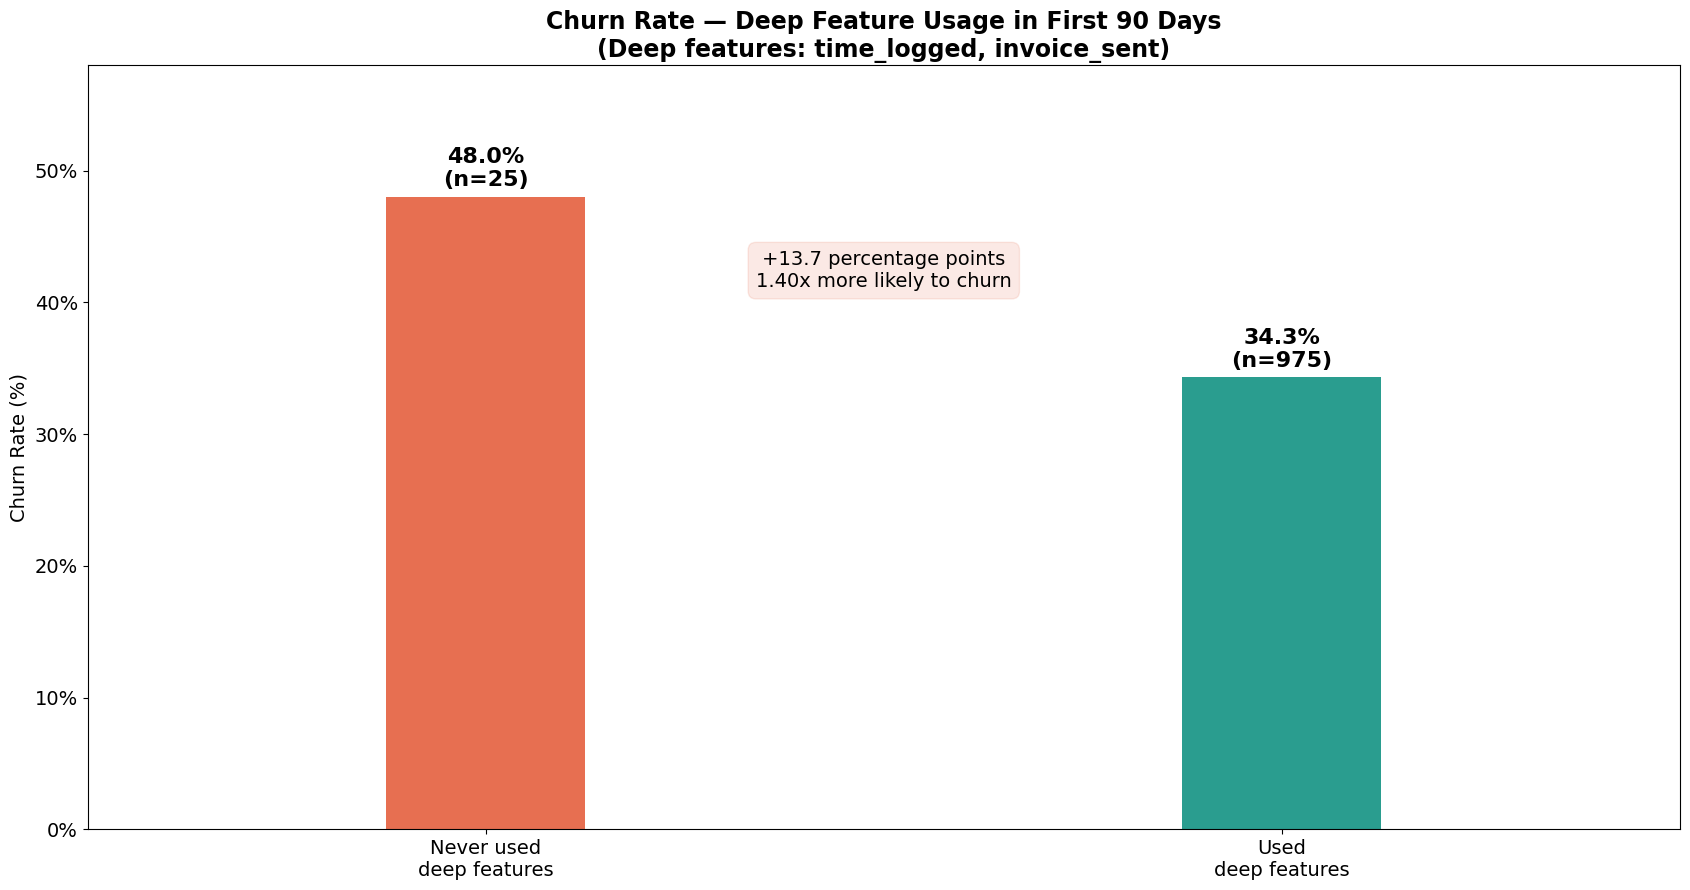

In [32]:
# ── KPI 11: Deep feature usage chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 9))

categories = ["Never used\ndeep features", "Used\ndeep features"]
values     = [churn_deep.iloc[0]["churn_rate"] * 100,
              churn_deep.iloc[1]["churn_rate"] * 100]
colors     = ["#E76F51", "#2A9D8F"]
n_labels   = [int(churn_deep.iloc[0]["n_customers"]),
              int(churn_deep.iloc[1]["n_customers"])]

bars = ax.bar(categories, values, color=colors, width=0.25)

# Value labels on top
for bar, val, n in zip(bars, values, n_labels):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%\n(n={n})",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold")

# Difference annotation
diff = values[0] - values[1]
ax.annotate(f"+{diff:.1f} percentage points\n1.40x more likely to churn",
            xy=(0.5, (values[0] + values[1]) / 2),
            xycoords=("axes fraction", "data"),
            ha="center", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="#E76F51", alpha=0.15,
                      edgecolor="#E76F51"))

ax.set_title("Churn Rate — Deep Feature Usage in First 90 Days\n"
             "(Deep features: time_logged, invoice_sent)",
             fontsize=17, fontweight="bold")
ax.set_ylabel("Churn Rate (%)", fontsize=14)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="both", labelsize=14)
ax.set_ylim(0, max(values) + 10)
ax.set_xlim(-0.5, 1.5)

plt.tight_layout()
plt.savefig("../images/fig_deep_feature_churn.png", dpi=150,
            bbox_inches="tight")
plt.show()

### KPI 11 — Deep Feature Usage vs Churn Rate (first 90 days)

| Segment | Customers | Churn Rate |
|---|---|---|
| Never used deep features | 25 | 48.0% |
| Used deep features | 975 | 34.3% |
| Difference | — | +13.7 percentage points |
| Relative risk | — | 1.40x more likely to churn |

**Deep features defined:** `time_logged` and `invoice_sent` —  
actions that signal an agency has integrated Flowmetric into its
core billing and time tracking workflow.

**Interpretation:**  
Customers who never log time or send invoices through Flowmetric
in their first 90 days are 40% more likely to cancel than those who do.
This makes intuitive business sense: an agency that tracks time and
invoices clients through the platform has high switching costs —
migrating away would disrupt their core revenue operations.

Customers who only use shallow features (login, project creation, task assignment)
without reaching the deeper workflow are not yet "locked in" and churn at
significantly higher rates.

**Recommendation:**  
Define "deep feature activation" as a north-star onboarding metric.
Target: 80%+ of new customers should use `time_logged` or `invoice_sent`
within 90 days of signup. Customers who haven't activated by day 45
should receive a proactive customer success intervention.

### KPI 12 — Cohort Retention

In [33]:
# ── KPI 12: Cohort Retention Table ────────────────────────────────────────
# Group customers by signup quarter.
# For each cohort track % still active at months 3, 6, 9, 12, 18, 24.

customers_clean["signup_quarter"] = (
    customers_clean["signup_date"].dt.to_period("Q")
)

checkpoints = [3, 6, 9, 12, 18, 24]
cohort_rows = []

for quarter, group in customers_clean.groupby("signup_quarter"):
    cids       = group["customer_id"].values
    signup_ts  = pd.Timestamp(str(quarter.start_time))
    row        = {"cohort": str(quarter), "n_customers": len(cids)}

    for cp in checkpoints:
        check_date = signup_ts + pd.DateOffset(months=cp)
        if check_date > ANALYSIS_DATE:
            row[f"month_{cp}"] = np.nan
            continue

        still_active = 0
        for cid in cids:
            alive = subs_clean[
                (subs_clean["customer_id"] == cid) &
                (subs_clean["start_date"]   <= check_date) &
                (subs_clean["end_date_filled"] >= check_date)
            ]
            if not alive.empty:
                still_active += 1

        row[f"month_{cp}"] = still_active / len(cids)

    cohort_rows.append(row)

cohort_df = pd.DataFrame(cohort_rows).set_index("cohort")
retention_cols    = [f"month_{c}" for c in checkpoints]
retention_matrix  = cohort_df[retention_cols]

print("Cohort Retention Table:")
print((retention_matrix * 100).round(1).to_string())

Cohort Retention Table:
        month_3  month_6  month_9  month_12  month_18  month_24
cohort                                                         
2023Q3    100.0     82.8     82.8      75.9      62.1      51.7
2023Q4     91.1     84.4     80.0      75.6      64.4      53.3
2024Q1     98.1     88.5     78.8      75.0      67.3      59.6
2024Q2     90.0     81.4     75.7      64.3      51.4      44.3
2024Q3     96.6     92.0     82.8      77.0      62.1       NaN
2024Q4     96.3     87.7     76.5      70.4      60.5       NaN
2025Q1     90.6     81.2     74.1      65.9       NaN       NaN
2025Q2     97.8     82.6     72.8      65.2       NaN       NaN
2025Q3     94.8     88.8     78.4       NaN       NaN       NaN
2025Q4     93.0     87.0      NaN       NaN       NaN       NaN
2026Q1     94.0      NaN      NaN       NaN       NaN       NaN
2026Q2      NaN      NaN      NaN       NaN       NaN       NaN


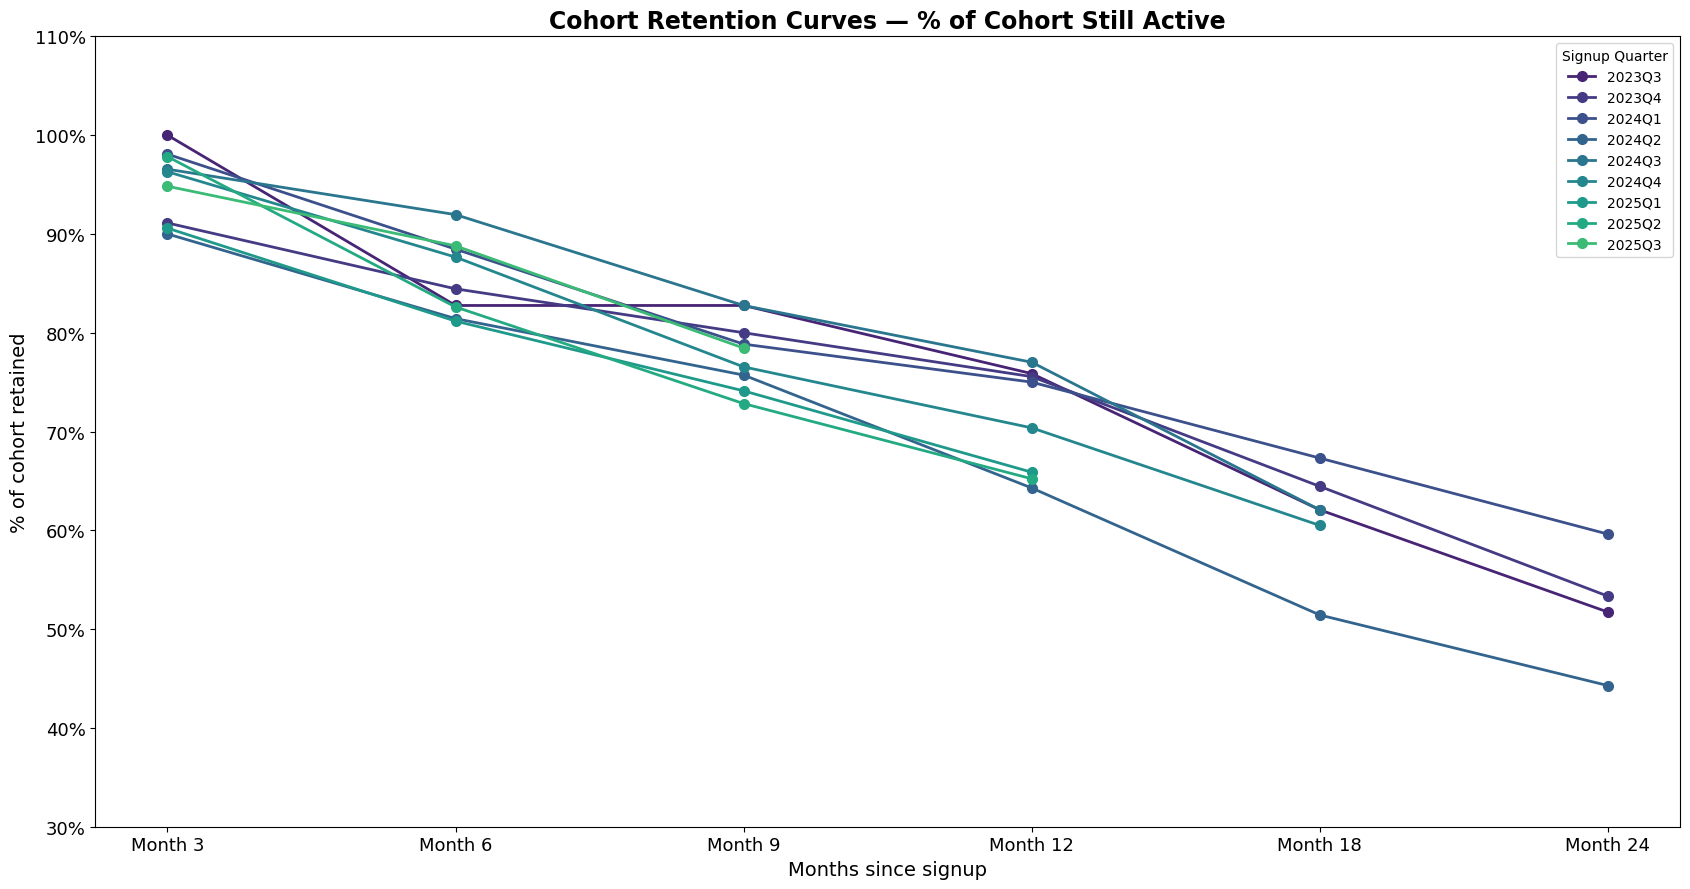

In [34]:
# ── KPI 12: Cohort retention — line chart ─────────────────────────
fig, ax = plt.subplots(figsize=(17, 9))

palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(retention_matrix)))

for i, (cohort, row) in enumerate(retention_matrix.iterrows()):
    valid = row.dropna()
    if len(valid) < 3:
        continue
    ax.plot(
        valid.index.str.replace("month_", "Month "),
        valid.values * 100,
        marker="o", linewidth=2, markersize=7,
        label=cohort, color=palette[i]
    )

ax.set_title("Cohort Retention Curves — % of Cohort Still Active",
             fontsize=17, fontweight="bold")
ax.set_ylabel("% of cohort retained", fontsize=14)
ax.set_xlabel("Months since signup", fontsize=14)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="both", labelsize=13)
ax.set_ylim(30, 110)
ax.legend(loc="upper right", fontsize=10, title="Signup Quarter")

plt.tight_layout()
plt.savefig("../images/fig_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI 12 — Cohort Retention

| Cohort | Month 3 | Month 6 | Month 9 | Month 12 | Month 18 | Month 24 |
|---|---|---|---|---|---|---|
| 2023Q3 | 100% | 83% | 83% | 76% | 62% | 52% |
| 2023Q4 | 91% | 84% | 80% | 76% | 64% | 53% |
| 2024Q1 | 98% | 88% | 79% | 75% | 67% | 60% |
| 2024Q2 | 90% | 81% | 76% | 64% | 51% | 44% |
| 2024Q3 | 97% | 92% | 83% | 77% | 62% | — |
| 2024Q4 | 96% | 88% | 77% | 70% | 61% | — |

**Interpretation:**  
Retention drops most sharply between Month 3 and Month 9 — this is the
critical churn window. Customers who survive past Month 9 tend to stabilise
and remain active long-term, suggesting the product delivers enough value
to retain committed users.

2024Q1 is the strongest cohort (60% retained at 24 months) while 2024Q2
is the weakest (44% at 24 months) — a 16 percentage point difference that
warrants investigation into what changed between those two quarters
(pricing change, product issue, or sales quality).

**Recommendation:**  
Month 9 survival should be a north-star retention metric. Onboarding
and customer success efforts should be concentrated in the first 9 months,
particularly between Month 3 and Month 6 where the steepest drop occurs.

## Key Findings & Recommendations

### Finding 1 — Revenue is growing but dependent on acquisition
MRR grew ~60x over 36 months (€3.7k → €222k), driven almost entirely by new
customer acquisition. NRR of 85.4% (below the 100% industry benchmark) means
existing customers alone are not sustaining revenue. If acquisition slows,
growth stalls immediately.

**Action:** Invest in upsell and expansion programmes to move NRR above 100%.

---

### Finding 2 — Churn is a Starter plan problem
Starter churn rate (52.1%) is 5x higher than Enterprise (10.1%).
Contraction MRR (€18.7k) exceeds Expansion MRR (€7k) — customers are
downgrading before cancelling, a classic pre-churn signal.

**Action:** Build a dedicated 30-day onboarding flow for Starter customers
to accelerate time-to-value and reduce early churn.

---

### Finding 3 — Enterprise customers are disproportionately valuable
Enterprise LTV (€10,670) is 17x higher than Starter (€618). Despite
representing only 21.8% of customers, Enterprise generates 68% of total revenue.
All three plans have healthy LTV/CAC ratios (>3x).

**Action:** Shift sales and marketing investment toward mid-market and enterprise
segments where LTV justifies higher acquisition costs.

---

### Finding 4 — Early engagement predicts churn
Customers who churn average 11.7% fewer product events in their first 30 days
(statistically significant, p=0.0002). Customers who never use deep features
(time_logged, invoice_sent) in the first 90 days are 1.40x more likely to churn.

**Action:** Define deep feature activation as a north-star onboarding metric.
Trigger customer success outreach for customers below 14 events at day 14,
or who haven't used time_logged or invoice_sent by day 45.

---

### Finding 5 — Month 9 is the critical retention threshold
Cohort retention drops most steeply between Month 3 and Month 9.
Customers who survive past Month 9 stabilise and become long-term users.
2024Q1 is the strongest cohort (60% at 24 months); 2024Q2 the weakest (44%).

**Action:** Concentrate customer success efforts in the first 9 months.
Investigate what changed between 2024Q1 and 2024Q2 that caused the retention drop.

---

*Analysis completed by Gabriel | Flowmetric SaaS Portfolio Project | July 2026*  
*Dataset: Synthetic data generated with realistic B2B SaaS business logic*  
*Tools: Python (pandas, matplotlib, seaborn, scipy) | SQL | Power BI*